# Feature Importance, Bootstrap, and Model Deployment
## ML Course 2026 | Chapter 2 (Hands-On Machine Learning (Géron))

This notebook covers the complete workflow of an ML project applied to the **California Housing** dataset:

from data loading to saving the production-ready model.

### Table of Contents
1. Data Loading and Exploration
2. Train/Test Split (Random, Hashed, Stratified)
3. Visual Exploration and Correlations
4. Cleaning and Imputation
5. Categorical Encoding
6. Feature Scaling (MinMax, Standardization, Transformations)
7. Function Transformer and Custom Transformers
8. Pipeline and Column Transformer
9. Model Training
10. Cross-Validation
11. GridSearchCV and RandomizedSearchCV
12. Halving Search
13. Feature Importance and SelectFromModel
14. Final Evaluation + Confidence Interval (Bootstrap)
15. Saving and Loading the Model with CloudPickle

## 0. Installing Dependencies

We install the necessary libraries for the entire notebook.
In Google Colab, they are usually pre-installed, but it's good practice to check versions.

| Library | Main Use |
|---|---|
`scikit-learn` | Models, transformers, pipelines, hyperparameter search |
`scipy` | Statistics, bootstrap, probability distributions |
`matplotlib` | Visualizations |
`pandas` | Tabular data manipulation |

In [1]:
!pip install scikit-learn scipy matplotlib pandas

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Importing and Loading Data

We import `pandas` and `polars` to demonstrate that the same analysis can be performed with both libraries.

In this course, we primarily use **Pandas**, but we show the equivalent syntax in **Polars** for comparison.


In [2]:
from pathlib import Path
import pandas as pd
import polars as pl
import tarfile
import urllib.request
import matplotlib.pyplot as plt

In [3]:
url = "https://github.com/ageron/data/raw/main/housing.tgz"

### 1.1 The `load_housing_data` Function

Downloads the `housing.tgz` dataset from GitHub the **first time** it is executed, decompresses it, and loads it as a DataFrame.

The `engine` argument allows you to choose between Pandas (`'pd'`) or Polars (`'pl'`).

> **Best practice:** Automating the download avoids manual steps and makes the code reproducible on any machine.

In [4]:
def load_housing_data(engine="pd"):
    project_root = Path().resolve().parents[2]

    data_dir = project_root / "data" / "raw"
    tarball_path = data_dir / "housing.tgz"
    csv_path = data_dir / "housing.csv"

    data_dir.mkdir(parents=True, exist_ok=True)

    if not csv_path.exists():
        if not tarball_path.exists():
            urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as tar:
            tar.extractall(path=data_dir)
    # project_root = Path().resolve().parents[2]
    # data_dir = project_root / "data" / "raw"
    # print(data_dir)
    # print(csv_path.exists())

    if engine == "pl":
        return pl.read_csv(csv_path)
    elif engine == "pd":
        return pd.read_csv(csv_path)
    else:
        raise ValueError("Invalid engine. Use 'pl' or 'pd'.")

In [5]:
housing_pd = load_housing_data()
housing_pl = load_housing_data('pl')

### 1.2 Quick Overview of the Dataset

Using `.head()` we see the first few rows: **10 columns**, 9 numeric and 1 categorical (`ocean_proximity`).
Each row represents a **census ward** of California.

In [6]:
housing_pd.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [7]:
housing_pl.head()

longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
f64,f64,f64,f64,f64,f64,f64,f64,f64,str
-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,"""NEAR BAY"""
-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,"""NEAR BAY"""
-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,"""NEAR BAY"""
-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,"""NEAR BAY"""
-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,"""NEAR BAY"""


### 1.3 `.info()` (Dataset Structure)

Displays data types and non-null values. We detected that `total_bedrooms` has **207 missing values** (20640 - 20433).

This should be addressed before training any model.

In [8]:
housing_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


### 1.4 Inspecting Rows with NaN in `total_bedrooms`

We locate rows with missing values ​​to understand the scope of the problem before deciding how to impute them.

In [9]:
housing_pd[housing_pd["total_bedrooms"].isna()]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
182,-118.27,34.04,13.0,1784.0,NaN,2158.0,682.0,1.7038,118100.0,<1H OCEAN
327,-117.65,34.04,15.0,3393.0,NaN,2039.0,611.0,3.9336,151000.0,INLAND
366,-122.50,37.75,44.0,1819.0,NaN,1137.0,354.0,3.4919,271800.0,NEAR OCEAN
477,-117.99,34.14,30.0,2346.0,NaN,1988.0,474.0,2.5625,153000.0,INLAND
495,-114.59,34.83,41.0,812.0,NaN,375.0,158.0,1.7083,48500.0,INLAND
...,...,...,...,...,...,...,...,...,...,...
19880,-118.23,33.94,36.0,1110.0,NaN,1417.0,302.0,2.3333,92100.0,<1H OCEAN
19952,-119.19,34.20,18.0,3620.0,NaN,3171.0,779.0,3.3409,220500.0,NEAR OCEAN
20088,-119.73,36.83,8.0,3602.0,NaN,1959.0,580.0,5.3478,138800.0,INLAND
20325,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,410700.0,<1H OCEAN


In [10]:
housing_pl.glimpse()

Rows: 20640
Columns: 10
$ longitude          <f64> -122.23, -122.22, -122.24, -122.25, -122.25, -122.25, -122.25, -122.25, -122.26, -122.25
$ latitude           <f64> 37.88, 37.86, 37.85, 37.85, 37.85, 37.85, 37.84, 37.84, 37.84, 37.84
$ housing_median_age <f64> 41.0, 21.0, 52.0, 52.0, 52.0, 52.0, 52.0, 52.0, 42.0, 52.0
$ total_rooms        <f64> 880.0, 7099.0, 1467.0, 1274.0, 1627.0, 919.0, 2535.0, 3104.0, 2555.0, 3549.0
$ total_bedrooms     <f64> 129.0, 1106.0, 190.0, 235.0, 280.0, 213.0, 489.0, 687.0, 665.0, 707.0
$ population         <f64> 322.0, 2401.0, 496.0, 558.0, 565.0, 413.0, 1094.0, 1157.0, 1206.0, 1551.0
$ households         <f64> 126.0, 1138.0, 177.0, 219.0, 259.0, 193.0, 514.0, 647.0, 595.0, 714.0
$ median_income      <f64> 8.3252, 8.3014, 7.2574, 5.6431, 3.8462, 4.0368, 3.6591, 3.12, 2.0804, 3.6912
$ median_house_value <f64> 452600.0, 358500.0, 352100.0, 341300.0, 342200.0, 269700.0, 299200.0, 241400.0, 226700.0, 261100.0
$ ocean_proximity    <str> 'NEAR BAY', 'NEAR BAY'

In [11]:
housing_pl.null_count()

longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,207,0,0,0,0,0


### 1.5 `.value_counts()` (Categorical Distribution)

`ocean_proximity` has 5 categories. The most frequent is `<1H OCEAN` (~9,136 districts).
This column is a **categorical attribute** that we will later encode with `OneHotEncoder`.

In [12]:
housing_pd["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [13]:
housing_pl["ocean_proximity"].value_counts()

ocean_proximity,count
str,u32
"""INLAND""",6551
"""ISLAND""",5
"""NEAR BAY""",2290
"""NEAR OCEAN""",2658
"""<1H OCEAN""",9136


### 1.6 `.describe()` (Descriptive Statistics)

Displays the mean, standard deviation, minimum, maximum, and quartiles for each numeric column.

Key observations:
- `median_income` is on a scale of 0–15 (not in actual dollars)
- `median_house_value` is capped at 500,000 (this could bias the model)
- The scales are very different across columns → we will need feature scaling

In [14]:
housing_pd.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [15]:
housing_pl.describe()

statistic,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""count""",20640.0,20640.0,20640.0,20640.0,20433.0,20640.0,20640.0,20640.0,20640.0,"""20640"""
"""null_count""",0.0,0.0,0.0,0.0,207.0,0.0,0.0,0.0,0.0,"""0"""
"""mean""",-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.53968,3.870671,206855.816909,null
"""std""",2.003532,2.135952,12.585558,2181.615252,421.38507,1132.462122,382.329753,1.899822,115395.615874,null
"""min""",-124.35,32.54,1.0,2.0,1.0,3.0,1.0,0.4999,14999.0,"""<1H OCEAN"""
"""25%""",-121.8,33.93,18.0,1448.0,296.0,787.0,280.0,2.5637,119600.0,null
"""50%""",-118.49,34.26,29.0,2127.0,435.0,1166.0,409.0,3.5349,179700.0,null
"""75%""",-118.01,37.71,37.0,3148.0,647.0,1725.0,605.0,4.7431,264700.0,null
"""max""",-114.31,41.95,52.0,39320.0,6445.0,35682.0,6082.0,15.0001,500001.0,"""NEAR OCEAN"""


### 1.7 Histograms of Numerical Attributes

Many distributions have a **skewed right** tail. This can distort linear models.
We will apply logarithmic transformations later to correct this.

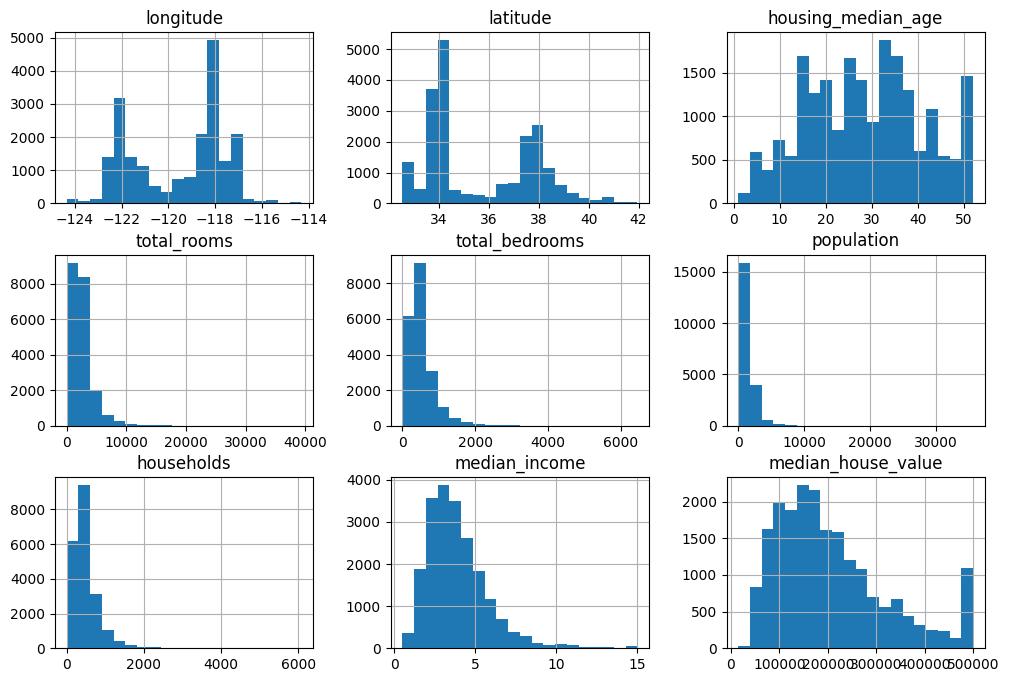

In [16]:
housing_pd.hist(bins=20, figsize=(12, 8))
plt.show()

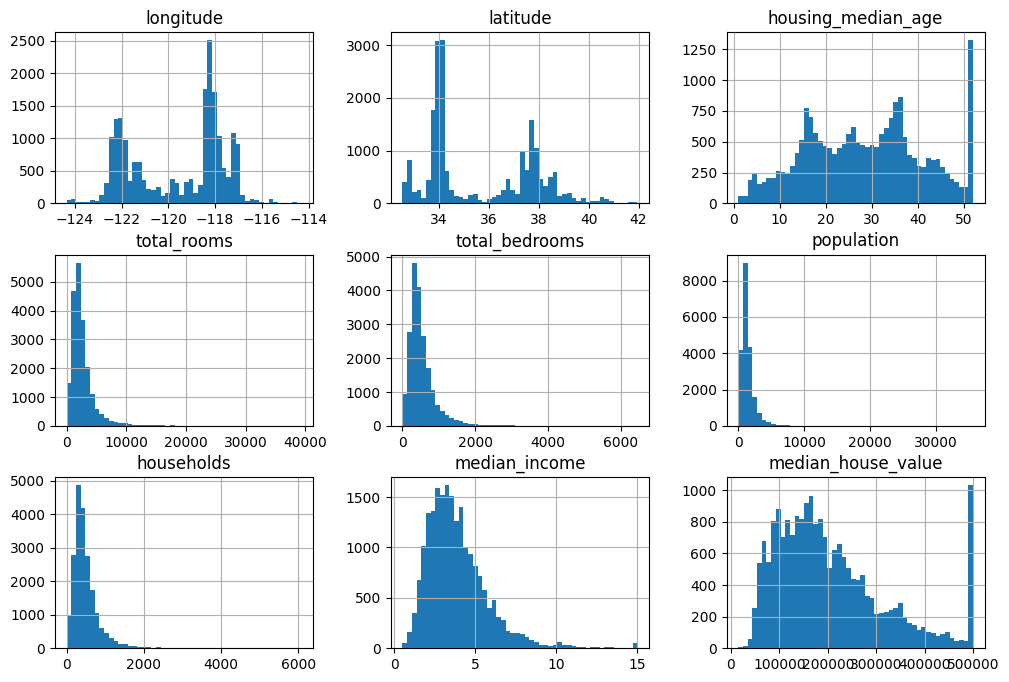

In [17]:
housing_pl_df = housing_pl.to_pandas()
housing_pl_df.hist(bins=50, figsize=(12, 8))
plt.show()

---
## 2. Train/Test Split

Separating the test set **before any analysis** is crucial to avoid **data snooping bias**:

if we explore the test set, we unconsciously adapt our decisions to it, and the model appears better than it actually is.

### 2.1 Simple Random Shuffle

The most basic approach: shuffle the indices randomly and take 20% as the test set.

> **Problem:** If the dataset is updated, the split changes, and data that was in the train set may appear in the test set.

# random mix

In [18]:
import numpy as np

def shuffle_and_split_data(data, test_ratio, rng):
    # Generates a random permutation of the dataset indices
    # rng is a random number generator (for example, np.random.default_rng(seed))
    shuffled_indices = rng.permutation(len(data)) # [4,2,3,1]

    # Calculates how many rows will go to the test set
    test_set_size = int(len(data) * test_ratio)

    # Takes the first indices (already shuffled) for the test set
    test_indices = shuffled_indices[:test_set_size]

    # The rest of the indices will be for the train set
    train_indices = shuffled_indices[test_set_size:]

    # Returns two subsets using iloc (position-based indexing)
    # First the train set, then the test set
    return data.iloc[train_indices], data.iloc[test_indices]

In [19]:
# Random number generator
rng = np.random.default_rng(seed=42) 

In [20]:
train_set, test_set = shuffle_and_split_data(housing_pd, 0.2, rng)

In [21]:
train_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
18731,-117.07,32.80,36.0,2028.0,349.0,820.0,352.0,3.9828,168900.0,<1H OCEAN
3002,-122.45,37.71,50.0,1441.0,283.0,1159.0,286.0,4.5417,233700.0,NEAR OCEAN
19844,-118.33,33.82,26.0,5591.0,934.0,2824.0,939.0,6.5861,417800.0,<1H OCEAN
4939,-122.20,37.43,38.0,3626.0,528.0,1350.0,532.0,7.3681,500001.0,NEAR OCEAN
1674,-121.47,38.54,47.0,2085.0,464.0,1346.0,402.0,1.2679,56700.0,INLAND


### 2.2 Split by ID Hash

**Solution to the problem of changing datasets:** Use a hash of the ID of each instance.

- If the ID is stable (doesn't change even if new rows are added), the split will also be stable.
- `crc32` transforms an integer into a 32-bit hash in a deterministic way.

# Split by identifier hash

In [22]:
from zlib import crc32
import numpy as np

def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32

### `crc32(...)`

Produces an integer in the range:

```
[0, 2³² − 1] = [0, 4,294,967,295]
```

In [23]:
crc32(np.int64(100))

830697768

In [24]:
crc32(np.int64(101))

4247351734

In [25]:
crc32(np.int64(3))

3954038922

In [26]:
crc32(np.int64(1))

2844319735

### Threshold

If `test_ratio = 0.2`:

```
0.2 × 4,294,967,296 = 858,993,459
```

Hashes less than that value → **test**. The rest → **train**.

In [27]:
def split_data_with_id_hash(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

In [28]:
# Add an `index` column
housing_with_id = housing_pd.reset_index()  
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "index")

In [29]:
len(train_set)

16512

In [30]:
len(test_set)

4128

In [31]:
train_set.head()

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
3,3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
6,6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY


### 2.3 Unique Identifier Construction

The dataset does not have a natural ID. We combined `longitude * 1000 + latitude` to create a stable one.

> Note: If several districts share exact coordinates, they could be incorrectly assigned to the same split.

# Building a Unique Identifier

If you're going to use the row index as a unique identifier to build a stable test set (for example, using hashing), you must guarantee two things:

- That new data is always appended to the end of the dataset.

- That existing rows are never deleted.

If any row is deleted or the dataset is reordered, the indices change and the split becomes inconsistent: observations that were previously in the train set could move to the test set (or vice versa).

If you can't guarantee this stability, then you must build a unique identifier using features that don't change over time.

In [32]:
housing_with_id["id"] = (housing_pd["longitude"] * 1000
                         + housing_pd["latitude"])
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "id")

In [33]:
train_set.head()

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,id
0,0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,-122192.12
1,1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,-122182.14
2,2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,-122202.15
3,3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,-122212.15
4,4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,-122212.15


### 2.4 Scikit-Learn's `train_test_split`

The most practical way. It's equivalent to the previous manual function but:
- Accepts `random_state` for reproducibility
- Can split multiple DataFrames at once with the same indices

# SCKIT LEARN

In [34]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing_pd, test_size=0.2,
                                       random_state=80)

In [35]:
train_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
8639,-122.03,36.96,28.0,1607.0,421.0,926.0,385.0,2.4250,216100.0,NEAR OCEAN
7811,-118.04,34.12,39.0,2522.0,380.0,1113.0,357.0,5.2249,445200.0,INLAND
6773,-121.94,37.75,17.0,2559.0,370.0,1238.0,377.0,6.2781,269800.0,<1H OCEAN
2076,-117.72,34.10,46.0,2477.0,458.0,1034.0,455.0,5.5000,289700.0,INLAND
7709,-122.46,37.72,39.0,2254.0,NaN,1388.0,404.0,2.9688,232000.0,NEAR OCEAN


### 2.5 Creating Income Categories

To perform a **stratified** split, we need a categorical variable.

`pd.cut()` converts `median_income` (continuous) into 5 discrete categories.

> **Why stratify?** Median income is the best predictor of price. If the test set has a different income distribution, the evaluation will be biased.

# Creating categories with pandas

In [36]:
housing_pd["income_cat"] = pd.cut(
    housing_pd["median_income"],
    bins=[0.,1.5,3.0,4.5,6., np.inf],
    labels=[1,2,3,4,5]
)

In [37]:
housing_pd.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,5
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,5
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,5
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,4
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,3


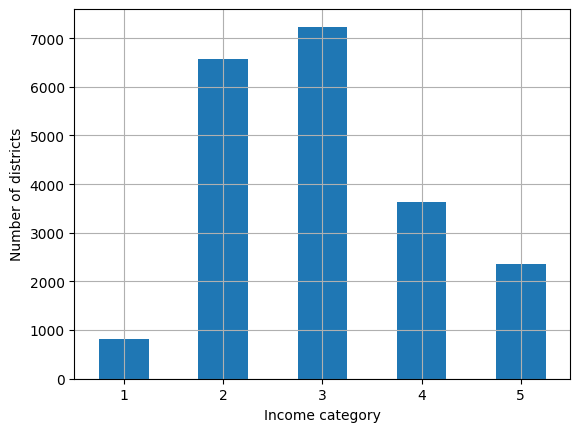

In [38]:
cat_counts = housing_pd["income_cat"].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

In [39]:
housing_pl = housing_pl.with_columns(
    pl.col("median_income")
    .cut(
        breaks=[1.5, 3.0, 4.5, 6.0],
        labels=["1", "2", "3", "4", "5"]
    )
    .alias("income_cat")
)



In [40]:
housing_pl.head()

longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
f64,f64,f64,f64,f64,f64,f64,f64,f64,str,cat
-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,"""NEAR BAY""","""5"""
-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,"""NEAR BAY""","""5"""
-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,"""NEAR BAY""","""5"""
-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,"""NEAR BAY""","""4"""
-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,"""NEAR BAY""","""3"""


### 2.6 `StratifiedShuffleSplit`

Splits the dataset **n_splits** times, maintaining the same proportion of each stratum in the train and test datasets.

Useful when multiple splits are needed for more robust error estimates.

# Stratifiedshufflesplit

In [41]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []
for train_index, test_index in splitter.split(housing_pd,
                                              housing_pd["income_cat"]):
    strat_train_set_n = housing_pd.iloc[train_index]
    strat_test_set_n = housing_pd.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

In [42]:
strat_train_set, strat_test_set = strat_splits[0]

### 2.7 `train_test_split` with `stratify`

A more concise way to perform a stratified split in a single line.

The argument `stratify=housing_pd["income_cat"]` ensures that the proportions of each income category are respected.

# train_test_split

In [43]:
strat_train_set, strat_test_set = train_test_split(
    housing_pd, test_size=0.2, stratify=housing_pd["income_cat"],
    random_state=42)

In [44]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [45]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

---
## 3. Visual Exploration and Correlations

We worked **only on the training set** (copy). We never explored the test set to avoid contaminating it.

### 3.1 Geographic Scatter Plots

We visualized longitude vs. latitude,  the result resembles a map of California.

With `alpha=0.2`, dense areas darken, making concentration patterns visible.

# Explore and Visualize

In [46]:
housing = strat_train_set.copy()

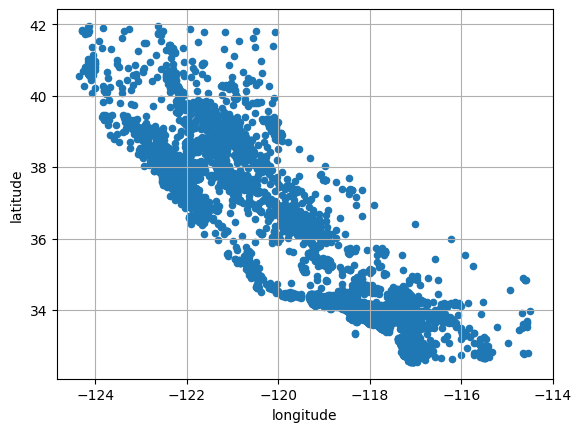

In [47]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True)
plt.show()

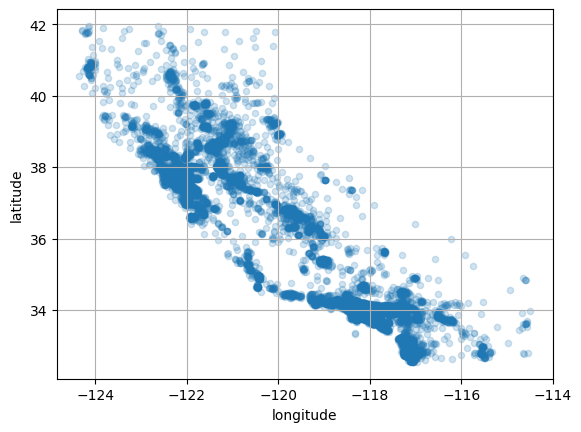

In [48]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
plt.show()

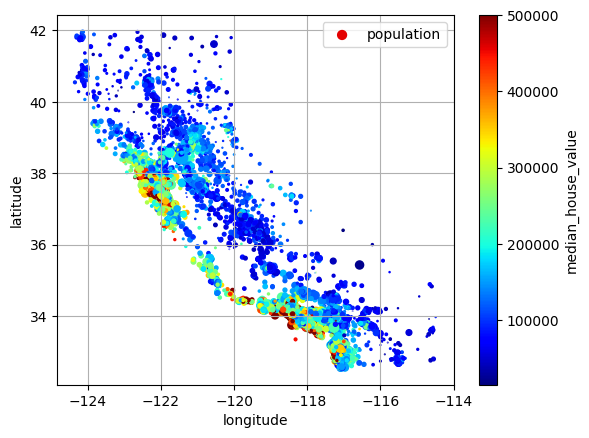

In [49]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=housing["population"] / 200, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, sharex=False)
plt.show()

### 3.2 Correlation Matrix

`df.corr()` calculates the **Pearson correlation coefficient** between each pair of numerical variables.

- Value in [-1, 1]
- Close to 1 → strong positive correlation
- Close to -1 → strong negative correlation
- Close to 0 → no linear correlation

`median_income` has the highest correlation with `median_house_value` (≈0.69).

In [50]:
corr_matrix = housing_pd.corr(numeric_only=True)

In [51]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

### 3.3 Feature Engineering (New Derived Attributes)

Creating new features by combining existing ones can reveal more useful relationships:

| New Feature | Formula | Why |
|---|---|---|
`rooms_per_house` | `total_rooms / households` | More informative than total rooms |
`bedrooms_ratio` | `total_bedrooms / total_rooms` | Houses with more bedrooms tend to be cheaper |
`people_per_house` | `population / households` | Household density |

`bedrooms_ratio` shows a stronger negative correlation than `total_bedrooms` alone.

In [52]:
housing_pd["rooms_per_house"] = housing_pd["total_rooms"] / housing_pd["households"]
housing_pd["bedrooms_ratio"] = housing_pd["total_bedrooms"] / housing_pd["total_rooms"]
housing_pd["people_per_house"] = housing_pd["population"] / housing_pd["households"]

In [53]:
corr_matrix = housing_pd.corr(numeric_only=True)

In [54]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
rooms_per_house       0.151948
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
people_per_house     -0.023737
population           -0.024650
longitude            -0.045967
latitude             -0.144160
bedrooms_ratio       -0.255880
Name: median_house_value, dtype: float64

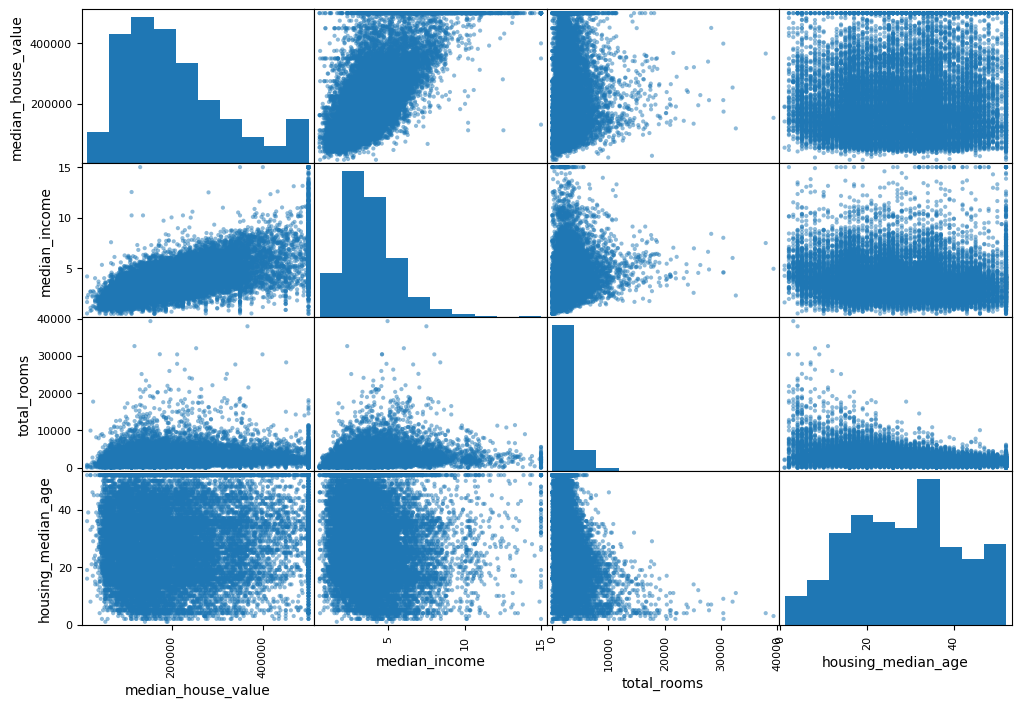

In [55]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms",
              "housing_median_age"]
scatter_matrix(housing_pd[attributes], figsize=(12, 8))
plt.show()

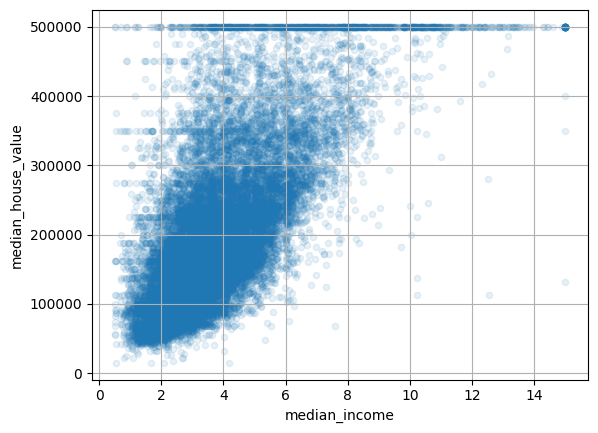

In [56]:
housing_pd.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1, grid=True)
plt.show()

---
## 4. Data Preparation (Separating X and Y)

We revert the exploratory changes and separate:
- `X` (features): all columns except the target
- `y` (labels): `median_house_value`

# Reverse everything

In [57]:
housing_pd = strat_train_set.drop("median_house_value", axis=1) # X
housing_labels_pd = strat_train_set["median_house_value"].copy() # y

### 4.1 `SimpleImputer` (Imputing Missing Values)

`total_bedrooms` has 207 NaN values. Possible strategies:
- `"median"` → replace with the column median (robust to outliers)
- `"mean"` → replace with the mean
- `"most_frequent"` → replace with the most common value (useful for categorical variables)

The imputer **learns the median** in `fit()` and applies it in `transform()`.

This ensures that the same value is used in train, validation, test, and production.

In [58]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

In [59]:
housing_num = housing.select_dtypes(include=[np.number])

In [60]:
imputer.fit(housing_num)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [61]:
imputer.statistics_

array([-1.1851e+02,  3.4260e+01,  2.9000e+01,  2.1250e+03,  4.3400e+02,
        1.1670e+03,  4.0800e+02,  3.5385e+00,  1.7920e+05])

In [62]:
X = imputer.transform(housing_num)

In [63]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing_num.index)

---
## 5. Encoding Categorical Attributes

ML models work with numbers. `ocean_proximity` (text) needs to be encoded.

### 5.1 `OrdinalEncoder`

Assigns an integer to each category: `<1H OCEAN=0`, `INLAND=1`, etc.

**Problem:** The model assumes that `INLAND(1)` is "more like" `<1H OCEAN(0)` than `NEAR OCEAN(4)`. 

This is false for nominal (unordered) categories.

# Categorical Attributes

In [64]:
housing_cat = housing_pd[["ocean_proximity"]]

In [65]:
housing_cat.value_counts()

ocean_proximity
<1H OCEAN          7274
INLAND             5301
NEAR OCEAN         2089
NEAR BAY           1846
ISLAND                2
Name: count, dtype: int64

In [66]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

In [67]:
housing_cat_encoded[:8] #SLICING

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.]])

In [68]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

---
### 5.2 `OneHotEncoder`

Creates one binary column per category. Only one column is valued at 1 ("hot") at a time.

- Does not impose order between categories
- Produces a sparse array by default (memory efficient)
- Remembers categories seen in train → detects unknown categories in production

In [69]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"

)

housing_cat_1hot = cat_encoder.fit_transform(housing_cat)


In [70]:
housing_cat_1hot

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

In [71]:
housing_cat_encoded = pd.DataFrame(
    housing_cat_1hot,
    columns=cat_encoder.get_feature_names_out(),
    index=housing_cat.index
)

In [72]:
housing_cat_encoded

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
13096,0.0,0.0,0.0,1.0,0.0
14973,1.0,0.0,0.0,0.0,0.0
3785,0.0,1.0,0.0,0.0,0.0
14689,0.0,1.0,0.0,0.0,0.0
20507,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...
14207,1.0,0.0,0.0,0.0,0.0
13105,0.0,1.0,0.0,0.0,0.0
19301,0.0,0.0,0.0,0.0,1.0
19121,1.0,0.0,0.0,0.0,0.0


---
## 6. Feature Scaling

ML algorithms are sensitive to the scale of the data.

`median_income` ranges from 0 to 15, `total_rooms` ranges from 6 to 39,320 → the model would ignore income.

Two main strategies:

# Feature Scaling

## Min-Max

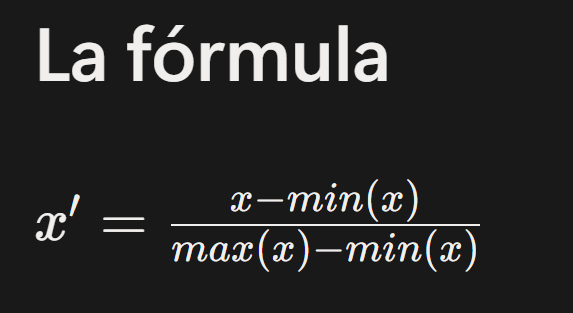

In [73]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

In [74]:

pd.DataFrame(housing_num_min_max_scaled, columns=housing_num.columns,
                          index=housing_num.index)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
13096,-0.608519,0.117021,1.000000,-0.831171,-0.641166,-0.807018,-0.614336,-0.779479,0.828038
14973,0.210953,-0.661702,0.529412,-0.900148,-0.886294,-0.918660,-0.867090,-0.229293,0.933192
3785,-0.519270,0.236170,0.254902,-0.945012,-0.930424,-0.931419,-0.924585,-0.733369,-0.642472
14689,0.468560,-0.744681,-0.372549,-0.787782,-0.726204,-0.774015,-0.709166,-0.756983,-0.665564
20507,0.257606,-0.740426,0.372549,-0.778015,-0.610243,-0.765796,-0.562815,-0.582171,0.430101
...,...,...,...,...,...,...,...,...,...
14207,0.206897,-0.721277,0.568627,-0.886312,-0.808021,-0.885290,-0.805115,-0.419236,1.000000
13105,0.022312,-0.197872,-0.137255,-0.850298,-0.809631,-0.826279,-0.801755,-0.714018,-0.695667
19301,0.478702,-0.991489,-0.529412,-0.800702,-0.750684,-0.655134,-0.716632,-0.508738,-0.448246
19121,0.206897,-0.678723,0.411765,-0.807773,-0.719117,-0.788738,-0.687512,-0.497166,1.000000


### 6.2 `StandardScaler` (Estandarización)

Formula: `z = (x - μ) / σ`

- Mean = 0, standard deviation = 1
- Does not bound values ​​within a fixed range
- **More robust to outliers** than MinMaxScaler

> **Rule of thumb:** Adjust (`.fit()`) ONLY on train. Apply (`.transform()`) on everything else.

## Standarization
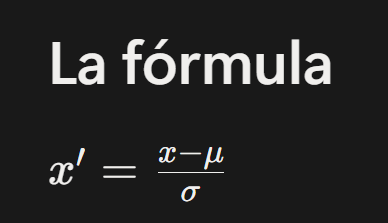

In [75]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

In [76]:
pd.DataFrame(housing_num_std_scaled, columns=housing_num.columns,
                          index=housing_num.index)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
13096,-1.423037,1.013606,1.861119,0.311912,1.359094,0.137460,1.394812,-0.936491,2.185112
14973,0.596394,-0.702103,0.907630,-0.308620,-0.436356,-0.693771,-0.373485,1.171942,2.406254
3785,-1.203098,1.276119,0.351428,-0.712240,-0.759584,-0.788768,-0.775727,-0.759789,-0.907406
14689,1.231216,-0.884924,-0.919891,0.702262,0.736231,0.383175,0.731375,-0.850281,-0.955971
20507,0.711362,-0.875549,0.589800,0.790125,1.585590,0.444376,1.755263,-0.180365,1.348242
...,...,...,...,...,...,...,...,...,...
14207,0.586397,-0.833359,0.987087,-0.184147,0.136961,-0.445315,0.060101,0.444041,2.546753
13105,0.131525,0.319822,-0.443146,0.139847,0.125165,-0.005950,0.083608,-0.685630,-1.019278
19301,1.256209,-1.428701,-1.237721,0.586026,0.556922,1.268299,0.679135,0.101049,-0.498944
19121,0.586397,-0.739605,0.669257,0.522417,0.788136,0.273563,0.882868,0.145396,2.546753


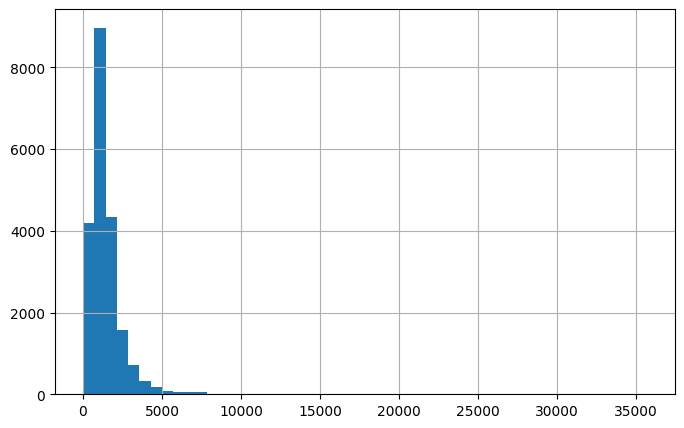

In [77]:
housing_pl_df["population"].hist(bins=50, figsize=(8,5))
plt.show()

### 6.3 Transformations for Heavy Tails

When a distribution has a **long right tail** (like `population`), scalers compress most values ​​into a small range.

Solutions:
- **Square root/power**: smooths the distribution
- **Logarithm**: very effective for power-law distributions
- **Bucketizing**: converts to ordinal or one-hot categories

## Transformations

In [78]:
housing_pl_df["population_sqrt"] = housing_pl_df["population"].pow(0.5)
housing_pl_df["population_log"] = housing_pl_df["population"].transform("log")

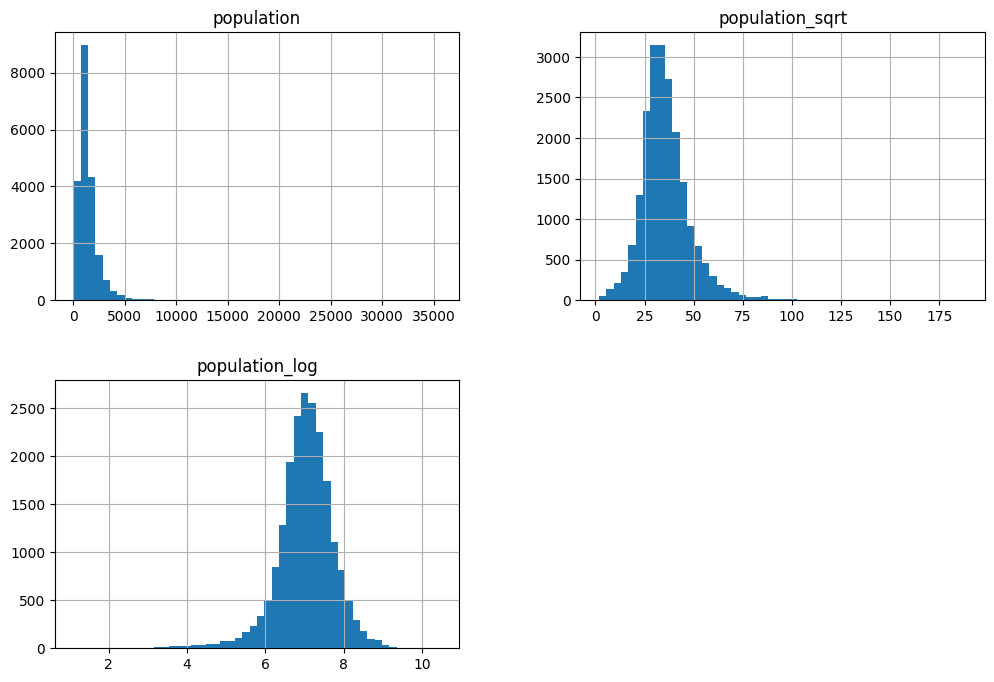

In [79]:
housing_pl_df[
    ["population", "population_sqrt", "population_log"]
].hist(bins=50, figsize=(12,8))

plt.show()

In [80]:
from sklearn.metrics.pairwise import rbf_kernel

age_simil_35 = rbf_kernel(
    housing[["housing_median_age"]],
    [[35]],
    gamma=0.1
)

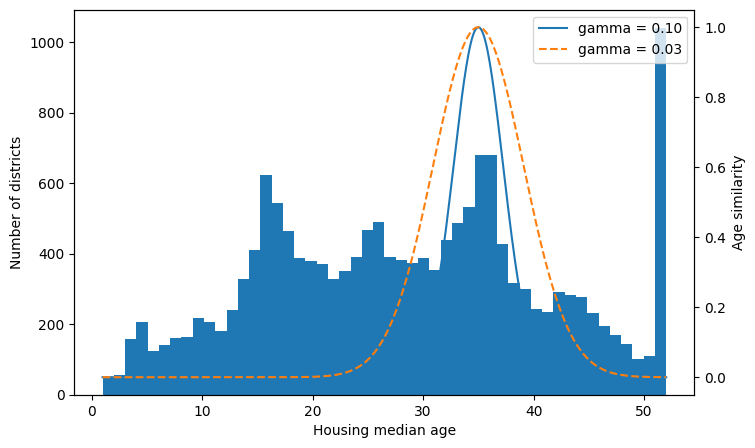

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import rbf_kernel


ages = housing["housing_median_age"].values

# Create a continuous age range to draw the curve
age_range = np.linspace(ages.min(), ages.max(), 500).reshape(-1,1)

# Calculate similarities
sim_gamma_01 = rbf_kernel(age_range, [[35]], gamma=0.1)
sim_gamma_003 = rbf_kernel(age_range, [[35]], gamma=0.03)

fig, ax1 = plt.subplots(figsize=(8,5))

# Histogram
ax1.hist(ages, bins=50)
ax1.set_xlabel("Housing median age")
ax1.set_ylabel("Number of districts")

# Second axis for similarity
ax2 = ax1.twinx()

ax2.plot(age_range, sim_gamma_01, label="gamma = 0.10")
ax2.plot(age_range, sim_gamma_003, linestyle="--", label="gamma = 0.03")

ax2.set_ylabel("Age similarity")

ax2.legend()

plt.show()

### 6.4 `RBF Kernel` (Gaussian Similarity)

`rbf_kernel(X, Y, gamma)` measures how "close" each point X is to a reference point Y.

It returns values ​​in [0, 1]: 1 = identical, 0 = very distant.

It is used to create geographic similarity features (`ClusterSimilarity`).

# TransformedTargetRegressor (MANUAL)

In [82]:
from sklearn.linear_model import LinearRegression

target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(housing_labels_pd.to_frame())

model = LinearRegression()
model.fit(housing[["median_income"]], scaled_labels)
some_new_data = housing[["median_income"]].iloc[:5]

scaled_predictions = model.predict(some_new_data)
predictions = target_scaler.inverse_transform(scaled_predictions)

In [83]:
scaled_predictions

array([[-0.64466228],
       [ 0.80674175],
       [-0.52302364],
       [-0.5853166 ],
       [-0.12415952]])

In [84]:
predictions

array([[131997.15275877],
       [299359.35844434],
       [146023.37185694],
       [138840.33653057],
       [192016.61557639]])

### 6.5 `TransformedTargetRegressor` (Scaling the Target)

Sometimes the target (price) should also be scaled before training.

`TransformedTargetRegressor` wraps the model and the target scaler:
- In `.fit()`: scales `y` and trains the model
- In `.predict()`: predicts and automatically reverses the transformation

> Avoids manual errors of forgetting to apply `inverse_transform`.

# TransformedTargetRegressor - Automatico

In [85]:
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(
    LinearRegression(),
    transformer=StandardScaler()
)

model.fit(housing[["median_income"]], housing_labels_pd)
predictions = model.predict(some_new_data)

In [86]:
predictions

array([131997.15275877, 299359.35844434, 146023.37185694, 138840.33653057,
       192016.61557639])

---
## 7. `FunctionTransformer` and Custom Transformers

### 7.1 `FunctionTransformer`

Converts **any Python function** into a Scikit-Learn compatible transformer (`.fit()`, `.transform()`).

Ideal for transformations without learned parameters, such as `np.log`.

# Function Transformer

In [87]:
from sklearn.preprocessing import FunctionTransformer
import numpy as np

# Define a custom transformation function
def log_transform(X):
    return np.log1p(X)

# Create a FunctionTransformer using the custom function
transformer = FunctionTransformer(log_transform)

In [88]:
X = np.array([1, 10, 100])
result = transformer.transform(X)
print(result)

[0.69314718 2.39789527 4.61512052]


In [89]:
from sklearn.pipeline import Pipeline
pipe = Pipeline([
    ('log', FunctionTransformer(log_transform)),
    ('scaler', StandardScaler()),
])

X = np.array([[1], [10], [100]])

result = pipe.fit_transform(X)

print(result)

[[-1.16808052]
 [-0.10638781]
 [ 1.27446833]]


### 7.2 Custom Transformer with `BaseEstimator` + `TransformerMixin`

For transformations that **learn parameters** in `.fit()` (such as the mean and standard deviation),

we create a class that inherits from:
- `BaseEstimator` → adds `get_params()` / `set_params()` for hyperparameter lookup
- `TransformerMixin` → automatically adds `fit_transform()`

**Mandatory contract:**
- `fit(X, y=None)` → learns parameters, returns `self`
- `transform(X)` → applies the transformation, returns an array

# Custom Transformer

In [90]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

class MiStandardScaler(BaseEstimator, TransformerMixin):

    def __init__(self):
        pass

    def fit(self, X, y=None):
        # Calculate mean for each column
        self.media_ = np.mean(X, axis=0)

        # Calculate standard deviation for each column
        self.std_ = np.std(X, axis=0)

        return self

    def transform(self, X, y=None):
        # Handle the case where std is zero to avoid division by zero
        std_safe = np.where(self.std_ == 0, 1, self.std_)

        # Apply the standardization formula
        return (X - self.media_) / std_safe

In [91]:
from sklearn.pipeline import Pipeline
pipe = Pipeline([
    ('log', FunctionTransformer(log_transform)),
    ('scaler', MiStandardScaler()),
])

X = np.array([[1], [10], [100]])

result = pipe.fit_transform(X)

print(result)

[[-1.16808052]
 [-0.10638781]
 [ 1.27446833]]


### 7.3 `ClusterSimilarity` (Custom Transformer with K-Means)

K-Means divides the data into `k` clusters, seeking to minimize intra-cluster distance.

`ClusterSimilarity`:
1. In `fit()`: apply K-Means to latitude/longitude → find the `k` geographic centers
2. In `transform()`: for each cluster, calculate its Gaussian similarity (RBF) to each center

The result is `k` new features that represent the "proximity" to key populated areas of California.

# k-means

In [92]:
from sklearn.cluster import KMeans

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [93]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
similarities = cluster_simil.fit_transform(housing_pd[["latitude", "longitude"]])

In [94]:
similarities[:5].round(2)

array([[0.46, 0.  , 0.08, 0.  , 0.  , 0.  , 0.  , 0.98, 0.  , 0.  ],
       [0.  , 0.96, 0.  , 0.03, 0.04, 0.  , 0.  , 0.  , 0.11, 0.35],
       [0.34, 0.  , 0.45, 0.  , 0.  , 0.  , 0.01, 0.73, 0.  , 0.  ],
       [0.  , 0.27, 0.  , 0.46, 0.  , 0.  , 0.  , 0.  , 0.  , 0.89],
       [0.  , 0.94, 0.  , 0.11, 0.01, 0.  , 0.  , 0.  , 0.03, 0.53]])

## 1. `Pipeline`

Chains transformers and a final estimator into a single object.

Each step receives the output of the previous one, and Scikit-learn handles calling `fit_transform` in the intermediate steps and `fit` in the last one.

```
X → step_1 → step_2 → ... → model → ŷ
```

> **Rule:** all intermediate steps must implement `fit_transform`.
> 
> The last step can be a transformer or a predictor.

In [95]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

X_train = strat_train_set.drop(columns=["median_house_value", "ocean_proximity"])
y_train = strat_train_set["median_house_value"]

X_test = strat_test_set.drop(columns=["median_house_value", "ocean_proximity"])
y_test = strat_test_set["median_house_value"]

In [96]:
pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("modelo",  LinearRegression()),
])

pipe.fit(X_train, y_train)

rmse = root_mean_squared_error(y_test, pipe.predict(X_test))
print(f"RMSE in test: {rmse:,.0f}")


RMSE in test: 71,865


In [97]:
# See the steps
for name, obje in pipe.steps:
    print(f"'{name}'  →  {type(obje).__name__}")


'imputer'  →  SimpleImputer
'scaler'  →  StandardScaler
'modelo'  →  LinearRegression


In [98]:
# Access a step by name
print("Medians learned by the input:")
print(dict(zip(X_train.columns, pipe["imputer"].statistics_)))


Medians learned by the input:
{'longitude': -118.51, 'latitude': 34.26, 'housing_median_age': 29.0, 'total_rooms': 2125.0, 'total_bedrooms': 434.0, 'population': 1167.0, 'households': 408.0, 'median_income': 3.5385}


## 2. `make_pipeline`

Same idea as `Pipeline` but **generates the names automatically** from the class name.

Useful when you don't need to access the steps by name.

In [99]:
from sklearn.pipeline import make_pipeline

pipe2 = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LinearRegression(),
)

# Name are automatically generated based on the class names of the steps
for name, _ in pipe2.steps:
    print(name)


simpleimputer
standardscaler
linearregression


In [100]:
pipe2.fit(X_train, y_train)
rmse2 = root_mean_squared_error(y_test, pipe2.predict(X_test))
print(f"RMSE in test: {rmse2:,.0f}")

RMSE in test: 71,865


## 3. `ColumnTransformer`

The `housing` dataset has numeric columns and one categorical column (`ocean_proximity`).
`ColumnTransformer` applies different transformations to each group and concatenates the results.

```
              ┌─ numerical  ─►  Imputer → Scaler    ──────────────┐
X ────────────┤                                                   ├──► result
              └─ categorical ─►  OneHotEncoder  ──────────────────┘
```


In [101]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

X_train_f = strat_train_set.drop(columns="median_house_value")
y_train_f = strat_train_set["median_house_value"]

X_test_f = strat_test_set.drop(columns="median_house_value")
y_test_f = strat_test_set["median_house_value"]

cols_num = X_train_f.select_dtypes(include=np.number).columns.tolist()
cols_cat = ["ocean_proximity"]

print("Numerical:", cols_num)
print("Categorical:", cols_cat)

Numerical: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical: ['ocean_proximity']


In [102]:
preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ]), cols_num),

    ("cat", OneHotEncoder(handle_unknown="ignore"), cols_cat),
])

pipe3 = Pipeline([
    ("prep",   preprocessor),
    ("model", LinearRegression()),
])

pipe3.fit(X_train_f, y_train_f)
rmse3 = root_mean_squared_error(y_test_f, pipe3.predict(X_test_f))
print(f"RMSE in test (with ocean_proximity): {rmse3:,.0f}")

RMSE in test (with ocean_proximity): 71,003


In [103]:
# View the columns generated by the preprocessor
print("Resulting columns:")
print(preprocessor.get_feature_names_out().tolist())


Resulting columns:
['num__longitude', 'num__latitude', 'num__housing_median_age', 'num__total_rooms', 'num__total_bedrooms', 'num__population', 'num__households', 'num__median_income', 'cat__ocean_proximity_<1H OCEAN', 'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND', 'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN']


## 4. `make_column_transformer`

Concise version of `ColumnTransformer`: same logic, **automatic names**, without the `transformers=` key.


In [104]:
from sklearn.compose import make_column_transformer

prep2 = make_column_transformer(
    (Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ]), cols_num),

    (OneHotEncoder(handle_unknown="ignore"), cols_cat),
)

pipe4 = Pipeline([("prep", prep2), ("model", LinearRegression())])
pipe4.fit(X_train_f, y_train_f)

rmse4 = root_mean_squared_error(y_test_f, pipe4.predict(X_test_f))
print(f"RMSE in test: {rmse4:,.0f}")

print("\nAutomatic transformer names:")
for name, _, _ in prep2.transformers_:
    print(f"  {name}")


RMSE in test: 71,003

Automatic transformer names:
  pipeline
  onehotencoder


## 5. `make_column_selector`

Instead of typing column names, `make_column_selector` automatically detects them by data type.

This is useful when the dataset may change or has many columns.

| Parameter | Description |
|---|---|
`dtype_include` | Include columns of this type |
`dtype_exclude` | Exclude columns of this type |
`pattern` | Columns whose name matches a regular expression |


In [105]:
from sklearn.compose import make_column_selector

selector_num = make_column_selector(dtype_include=np.number)
selector_cat = make_column_selector(dtype_exclude=np.number)

# The selector is a function: it receives the DataFrame and returns the names
print("Numerics detected:", selector_num(X_train_f))
print("\nCategoricals detected:", selector_cat(X_train_f))


Numerics detected: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

Categoricals detected: ['ocean_proximity']


In [106]:
# Complete pipeline without writing any column names
prep_auto = make_column_transformer(
    (Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ]), make_column_selector(dtype_include=np.number)),

    (OneHotEncoder(handle_unknown="ignore"),
     make_column_selector(dtype_exclude=np.number)),
)

pipe5 = Pipeline([("prep", prep_auto), ("model", LinearRegression())])
pipe5.fit(X_train_f, y_train_f)

rmse5 = root_mean_squared_error(y_test_f, pipe5.predict(X_test_f))
print(f"RMSE in test: {rmse5:,.0f}")
print("✅ Without mentioning any column manually")

RMSE in test: 71,003
✅ Without mentioning any column manually


---
## 6. Complete Pipeline

Up to now, we've used simple pipelines with **Linear Regression**.

This book proposes a richer pipeline that includes:

| Step | What it does |
|---|---|
| Imputation | Fills null values ​​with the median |
| Ratio Features | Creates new columns: rooms/household, people/household |
| Logarithmic Transformation | Reduces the long tail in skewed variables |
| Geographic Similarity (K-Means) | Measures how close each district is to 10 clusters |
| One-Hot Encoding | Converts `ocean_proximity` to numeric columns |
| Standardization | Puts all variables on the same scale |

In [107]:

import numpy as np
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import root_mean_squared_error


### 6.1 Custom Transformer: `ClusterSimilarity`

This transformer uses K-Means to find 10 geographic clusters in the data and then measures how close each district is to each cluster.

> Why is it useful?
> 
> Latitude and longitude alone don't tell you much, but knowing
> "how close I am to the cluster in San Francisco"
> gives the model much richer geographic information.

In [108]:
class ClusterSimilarity(BaseEstimator, TransformerMixin):
    """
    Custom Transformer that:
    1. In `fit()` -> uses K-Means to find n clusters of geographic centers
    2. In `transform()` -> measures the RBF (Gaussian) similarity of each district with each center found
    """

    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        # K-Means searches for the central n_clusters in the training data
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        # Always return self in fit()
        return self  

    def transform(self, X):
        # rbf_kernel measures Gaussian similarity: values ​​close to 1 = very similar
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]


### 6.2 Auxiliary Functions for Ratios

Instead of creating the columns manually, we encapsulate them
in functions that the pipeline can reuse.

In [109]:
def column_ratio(X):
    """Divide column 0 by column 1. Ex: total_bedrooms / total_rooms"""
    return X[:, [0]] / X[:, [1]]

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=lambda f, n: ["ratio"]),
        StandardScaler()
    )

### 6.3 Building the complete pipeline

Here we combine **all** the steps into a single `ColumnTransformer`.

> Note: We use `remainder=default_num_pipeline` so that the column
> `housing_median_age` (which is not in any explicit group)
> is also processed instead of being discarded.


In [110]:
# Pipeline for features with skewed distribution (long tail)
# Applies: impute -> log -> standardize
log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),  # log reduces the tail
    StandardScaler()
)

# Pipeline for numerical features without special transformation
default_num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

# Geographic transformer: finds 10 clusters and measures similarity
cluster_simil = ClusterSimilarity(n_clusters=10)

# Pipeline for categorical variables
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),   # fills nulls with the most common category
    OneHotEncoder(handle_unknown="ignore")     # converts categories to 0/1 columns
)

# ColumnTransformer: applies the correct pipeline to each group of columns
preprocessing = ColumnTransformer([
    # Ratios: how many bedrooms per household, people per household, etc.
    ("bedrooms",         ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
    ("rooms_per_house",  ratio_pipeline(), ["total_rooms",    "households"]),
    ("people_per_house", ratio_pipeline(), ["population",     "households"]),

    # Log for variables with a long right tail (right-skewed)
    ("log", log_pipeline, ["total_bedrooms", "total_rooms",
                           "population", "households", "median_income"]),

    # Geographic similarity using K-Means
    ("geo", cluster_simil, ["latitude", "longitude"]),

    # One-Hot for the categorical variable
    ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
],
    # Columns that do not appear above (like housing_median_age)
    # are processed with the default numerical pipeline
    remainder=default_num_pipeline
)

print("Preprocessing pipeline built successfully")

Preprocessing pipeline built successfully


In [111]:
# Let's check how many features the pipeline generates
# We use X_train_f (already defined in the notebook)
housing_prepared = preprocessing.fit_transform(X_train_f)

print(f"Original shape:   {X_train_f.shape}")
print(f"Prepared shape:   {housing_prepared.shape}")
print(f"\nGenerated columns ({housing_prepared.shape[1]}):")
for col in preprocessing.get_feature_names_out():
    print(f"  {col}")

Original shape:   (16512, 9)
Prepared shape:   (16512, 24)

Generated columns (24):
  bedrooms__ratio
  rooms_per_house__ratio
  people_per_house__ratio
  log__total_bedrooms
  log__total_rooms
  log__population
  log__households
  log__median_income
  geo__Cluster 0 similarity
  geo__Cluster 1 similarity
  geo__Cluster 2 similarity
  geo__Cluster 3 similarity
  geo__Cluster 4 similarity
  geo__Cluster 5 similarity
  geo__Cluster 6 similarity
  geo__Cluster 7 similarity
  geo__Cluster 8 similarity
  geo__Cluster 9 similarity
  cat__ocean_proximity_<1H OCEAN
  cat__ocean_proximity_INLAND
  cat__ocean_proximity_ISLAND
  cat__ocean_proximity_NEAR BAY
  cat__ocean_proximity_NEAR OCEAN
  remainder__housing_median_age


---
## 7. Model Training and Evaluation

We now have the preprocessing pipeline ready.

Now we combine it with different models and compare their performance.

### How does the complete pipeline work?

```
Pipeline(
preprocessing -> transforms the data
model -> learns the patterns
)
```

> When calling `.fit(X, y)`, the pipeline first transforms X
> and then trains the model with the transformed data.
> When calling `.predict(X)`, it transforms X again and makes predictions.

### 7.1 Linear Regression

The simplest model. Learn a formula like this:

```
price = a1*income + a2*rooms + a3*age + ...
```

This is a good starting point, but it's limited because it assumes that the relationship between variables is always linear.

In [112]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

lin_reg = Pipeline([
    ("preprocessing", preprocessing),
    ("model", LinearRegression())
])

lin_reg.fit(X_train_f, y_train_f)

# RMSE on training: useful for detecting overfitting/underfitting
rmse_train_lin = root_mean_squared_error(y_train_f, lin_reg.predict(X_train_f))

# Cross-validation: this is the real evaluation during model comparison
lin_rmses = -cross_val_score(
    lin_reg, X_train_f, y_train_f,
    scoring="neg_root_mean_squared_error",
    cv=10
)

print("=== Linear Regression ===")
print(f"RMSE on training: {rmse_train_lin:,.0f}")
print(f"CV RMSE mean:     {lin_rmses.mean():,.0f}")
print(f"CV RMSE std:      {lin_rmses.std():,.0f}")
print()
print("If training << CV mean -> overfitting  (memorized the data)")
print("If training approx CV  -> correct balance")
print("If both are high       -> underfitting (very simple model)")

=== Linear Regression ===
RMSE on training: 69,261
CV RMSE mean:     69,931
CV RMSE std:      3,729

If training << CV mean -> overfitting  (memorized the data)
If training approx CV  -> correct balance
If both are high       -> underfitting (very simple model)


### 7.2 Decision Tree Regressor

A decision tree asks a series of questions to arrive at a prediction:

```
Income > 5?
  YES -> Near the ocean?
    YES -> $400,000
    NO -> $280,000
  NO -> $150,000
```

**Problem:** Without restrictions, the tree can grow indefinitely
until it memorizes EVERY row of the training set -> **severe overfitting**.

In [113]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = Pipeline([
    ("preprocessing", preprocessing),
    ("model", DecisionTreeRegressor(random_state=42))
])

tree_reg.fit(X_train_f, y_train_f)

# RMSE on training: with the tree we expect it to be close to 0
# because without constraints it memorizes every row of the training set
rmse_train_tree = root_mean_squared_error(y_train_f, tree_reg.predict(X_train_f))

# Cross-validation: reveals the real performance on unseen data
tree_rmses = -cross_val_score(
    tree_reg, X_train_f, y_train_f,
    scoring="neg_root_mean_squared_error",
    cv=10
)

print("=== Decision Tree Regressor ===")
print(f"RMSE on training: {rmse_train_tree:,.0f}")
print(f"CV RMSE mean:     {tree_rmses.mean():,.0f}")
print(f"CV RMSE std:      {tree_rmses.std():,.0f}")
print()
print("If training approx 0 but CV mean is high -> OVERFITTING")
print("The tree memorized the data instead of learning patterns")
print("The difference between training and CV is the key signal")

=== Decision Tree Regressor ===
RMSE on training: 0
CV RMSE mean:     67,046
CV RMSE std:      1,750

If training approx 0 but CV mean is high -> OVERFITTING
The tree memorized the data instead of learning patterns
The difference between training and CV is the key signal


### 7.3 Random Forest Regressor

Trains **many trees** on random subsets of data and features,

then **averages their predictions**.

> Since each tree sees different data and makes different errors,
> averaging the errors cancels them out -> less overfitting.

```
Tree 1 predicts: $380,000
Tree 2 predicts: $420,000
Tree 3 predicts: $395,000
-------------------------------
Final average: $398,000 <- more reliable than any single tree
```

In [114]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = Pipeline([
    ("preprocessing", preprocessing),
    ("model", RandomForestRegressor(random_state=42))
])

forest_reg.fit(X_train_f, y_train_f)

# RMSE on training: with Random Forest we expect it to be low
# but not zero like the Decision Tree, because it averages many trees
rmse_train_forest = root_mean_squared_error(y_train_f, forest_reg.predict(X_train_f))

# Cross-validation: real evaluation without touching the test set
forest_rmses = -cross_val_score(
    forest_reg, X_train_f, y_train_f,
    scoring="neg_root_mean_squared_error",
    cv=10
)

print("=== Random Forest Regressor ===")
print(f"RMSE on training: {rmse_train_forest:,.0f}")
print(f"CV RMSE mean:     {forest_rmses.mean():,.0f}")
print(f"CV RMSE std:      {forest_rmses.std():,.0f}")
print()
print("CV RMSE should be significantly better than tree/linear")
print("If training << CV mean -> there is still overfitting, but less than the tree alone")

=== Random Forest Regressor ===
RMSE on training: 17,518
CV RMSE mean:     47,169
CV RMSE std:      973

CV RMSE should be significantly better than tree/linear
If training << CV mean -> there is still overfitting, but less than the tree alone


In [115]:
rmse_test_lin    = root_mean_squared_error(y_test_f, lin_reg.predict(X_test_f))
rmse_test_tree   = root_mean_squared_error(y_test_f, tree_reg.predict(X_test_f))
rmse_test_forest = root_mean_squared_error(y_test_f, forest_reg.predict(X_test_f))

---
## 8. Cross-Validation

### Why isn't it enough to evaluate only the test set?

If we evaluate many models and choose the one with the best RMSE in the test set,
we are unwittingly **adjusting our choice to that specific data**.

The test set becomes "contaminated".

### What does cross-validation do?

It divides the **training set** into k parts (folds). In each iteration:
- Train with k-1 folds
- Evaluate with the remaining fold (data not seen)

```
Fold 1: [TEST][train][train][train][train]... -> score 1
Fold 2: [train][TEST][train][train][train]... -> score 2
Fold 3: [train][train][TEST][train][train]... -> score 3
...
Fold k: [train][train][train][train][TEST]... -> score k

Final RMSE = average of all scores
```

> **Important:** The test set (20%) is never touched in this process.
> Cross-validation occurs WITHIN the training set.

### 8.1 Cross-Validation for Decision Tree

In [116]:
from sklearn.model_selection import cross_val_score

# cross_val_score with scoring="neg_root_mean_squared_error"
# Scikit-Learn returns NEGATIVE values because its convention is
# "greater is better". We put the negative sign in front to convert them
# into positive, readable RMSEs.
tree_rmses = -cross_val_score(
    tree_reg,
    X_train_f,
    y_train_f,
    scoring="neg_root_mean_squared_error",
    cv=10  # k=10: divides into 10 folds, trains and evaluates 10 times
)

print("=== Cross-Validation Decision Tree (k=10) ===")
print(f"RMSE per fold:  {tree_rmses.round(0)}")
print(f"Mean:           {tree_rmses.mean():,.0f}")
print(f"Std. deviation: {tree_rmses.std():,.0f}")
print()
print("The standard deviation tells us how stable the model is")
print("If it is very high, the model is sensitive to which data it trains on")

=== Cross-Validation Decision Tree (k=10) ===
RMSE per fold:  [68148. 63843. 66033. 65264. 63322. 69182. 65604. 67085. 71366. 67118.]
Mean:           66,696
Std. deviation: 2,316

The standard deviation tells us how stable the model is
If it is very high, the model is sensitive to which data it trains on


### 8.2 Cross-Validation for Linear Regression

In [117]:
lin_rmses = -cross_val_score(
    lin_reg,
    X_train_f,
    y_train_f,
    scoring="neg_root_mean_squared_error",
    cv=10
)

print("=== Cross-Validation Linear Regression (k=10) ===")
print(f"Mean: {lin_rmses.mean():,.0f}")
print(f"Stddev: {lin_rmses.std():,.0f}")

=== Cross-Validation Linear Regression (k=10) ===
Mean: 70,000
Stddev: 3,946


### 8.3 Cross-Validation para Random Forest


In [118]:
# Nota: Random Forest es mas lento porque entrena muchos arboles
# Con cv=10 entrena el modelo 10 veces -> puede tardar unos segundos
forest_rmses = -cross_val_score(
    forest_reg,
    X_train_f,
    y_train_f,
    scoring="neg_root_mean_squared_error",
    cv=10
)

print("=== Cross-Validation Random Regression (k=10) ===")
print(f"Mean: {forest_rmses.mean():,.0f}")
print(f"Stddev: {forest_rmses.std():,.0f}")

=== Cross-Validation Random Regression (k=10) ===
Mean: 46,962
Stddev: 1,062


---
## 9. GridSearchCV (Hyperparameter Search)

### What are hyperparameters?

Hyperparameters are **parameters that you configure before training**,
unlike internal parameters that the model learns on its own (such as
regression weights).

Examples in Random Forest:
```
n_estimators = How many trees to build? (100? 500? 1000?)
max_features = How many features does each tree evaluate? (4? 6? 8?)
max_depth = How deep can the tree grow?

```

And in the preprocessing pipeline:
```
n_clusters = How many geographic clusters does ClusterSimilarity use?

```

### The problem: How to choose the right values?

Manually testing all combinations would result in:

```
3 values ​​of n_clusters × 3 values ​​of max_features = 9 combinations
And that's just for 2 hyperparameters!
```

**GridSearchCV automates this process:**
1. Receives a grid of values ​​to test
2. For each combination, performs cross-validation (k-fold)
3. Returns the best combination and the best model

### How does GridSearchCV work internally?

```
param_grid = {
   'n_clusters': [5, 10, 15],
   'max_features': [4, 6, 8]
}

            max_features=4 max_features=6 max_features=8
n_clusters=5 CV(3 folds) CV(3 folds) CV(3 folds)
n_clusters=10 CV(3 folds) CV(3 folds) CV(3 folds)
n_clusters=15 CV(3 folds) CV(3 folds) CV(3 folds)

Total training = 9 combinations × 3 folds = 27
```

Finally, it refines the best model on **all** the training data.

> **Rule of thumb:** If the best value is on the edge of the grid,

expand the range in that direction and search again.

### 9.1 Building the Complete GridSearchCV Pipeline

To use GridSearchCV with a pipeline, we need to **reference nested hyperparameters** using double underscores `__`:
```
"preprocessing__geo__n_clusters"
       |           |       |
  Pipeline   ColumnTrf Transformer
  Name           Name  Hyperparameter
```

Scikit-Learn automatically navigates through all levels of the pipeline.

In [119]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# We build the complete pipeline: preprocessing + model
# (separate from the previous forest_reg to avoid contaminating its state)
full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
])

### 9.2 Defining the Hyperparameter Grid

We can pass **a list of dictionaries**:
- Each dictionary defines an independent search subspace
- GridSearchCV explores all dictionaries

This is useful when we want to combine hyperparameters in a non-Cartesian way.

In [120]:
# Hyperparameter grid to explore
# ─────────────────────────────────────────────────────────────────────────────
# Subspace 1: small/medium n_clusters (5, 8, 10) × small max_features (4, 6, 8)
# Subspace 2: large n_clusters (10, 15)          × larger max_features (6, 8, 10)
#
# Why two subspaces?
#   With more clusters (more geo features), the model might need
#   more max_features to take advantage of them. We separate the spaces so
#   we don't train "silly" combinations like n_clusters=5, max_features=10.
# ─────────────────────────────────────────────────────────────────────────────
param_grid = [
    {
        "preprocessing__geo__n_clusters": [5, 8, 10],
        "random_forest__max_features": [4, 6, 8],
    },
    {
        "preprocessing__geo__n_clusters": [10, 15],
        "random_forest__max_features": [6, 8, 10],
    }
]

# Subspace 1: 3 × 3 = 9 combinations
# Subspace 2: 2 × 3 = 6 combinations
# Total:                15 combinations × 3 folds = 45 trainings
print("Search subspaces:")
print(f"  Subspace 1: {len(param_grid[0]['preprocessing__geo__n_clusters'])} × "
      f"{len(param_grid[0]['random_forest__max_features'])} = "
      f"{len(param_grid[0]['preprocessing__geo__n_clusters']) * len(param_grid[0]['random_forest__max_features'])} combinations")
print(f"  Subspace 2: {len(param_grid[1]['preprocessing__geo__n_clusters'])} × "
      f"{len(param_grid[1]['random_forest__max_features'])} = "
      f"{len(param_grid[1]['preprocessing__geo__n_clusters']) * len(param_grid[1]['random_forest__max_features'])} combinations")
print(f"  Total combinations: 15 × 3 folds = 45 trainings")

Search subspaces:
  Subspace 1: 3 × 3 = 9 combinations
  Subspace 2: 2 × 3 = 6 combinations
  Total combinations: 15 × 3 folds = 45 trainings


### 9.3 Running GridSearchCV

Key parameters:
- `cv=3` → 3-fold cross-validation per merge (faster than 10, sufficient for comparison)
- `scoring='neg_root_mean_squared_error'` → same metric as before
- `refit=True` (default) → upon completion, refit the best model with **all** the training data

In [121]:
# GridSearchCV receives the entire pipeline
# Using cv=3 results in 15 × 3 = 45 trainings of the entire pipeline
# (including preprocessing each time, which can be slow)
grid_search = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error"
)

grid_search.fit(X_train_f, y_train_f)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'preprocessing__geo__n_clusters': [5, 8, ...], 'random_forest__max_features': [4, 6, ...]}, {'preprocessing__geo__n_clusters': [10, 15], 'random_forest__max_features': [6, 8, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity

### 9.4 Inspection of the results

In [122]:
# ── Best combination found ────────────────────────────────────────────────────
print("=== Best hyperparameters ===")
print(grid_search.best_params_)
print()

# ── Best model score ───────────────────────────────────────────────────────────
# best_score_ is the mean CV score with the best combination
# Since we used neg_RMSE, we negate it to get the positive RMSE
best_rmse = -grid_search.best_score_
print(f"Best RMSE (CV mean): {best_rmse:,.0f}")
print()

# ── Comparison with our baseline ──────────────────────────────────────────────
print(f"Random Forest with defaults: {forest_rmses.mean():,.0f}")
print(f"Random Forest with GridSearchCV: {best_rmse:,.0f}")
print(f"Improvement: {forest_rmses.mean() - best_rmse:,.0f} USD less error")

=== Best hyperparameters ===
{'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}

Best RMSE (CV mean): 44,065

Random Forest with defaults: 46,962
Random Forest with GridSearchCV: 44,065
Improvement: 2,897 USD less error


### 9.5 Complete Results Table

`cv_results_` contains the RMSE for **each combination** and **each fold**.

This allows us to see how stable each setup is, not just which one won.

In [123]:
import pandas as pd

# Convert the results to a DataFrame to inspect them
cv_results = pd.DataFrame(grid_search.cv_results_)

# Select only the most informative columns
cols_interes = [
    "param_preprocessing__geo__n_clusters",
    "param_random_forest__max_features",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]

cv_tabla = cv_results[cols_interes].copy()

# Convert neg_RMSE to positive RMSE
cv_tabla["mean_rmse"] = -cv_tabla["mean_test_score"]
cv_tabla["std_rmse"]  = cv_tabla["std_test_score"]

# Rename for readability
cv_tabla = cv_tabla.rename(columns={
    "param_preprocessing__geo__n_clusters": "n_clusters",
    "param_random_forest__max_features": "max_features",
    "rank_test_score": "rank",
})

# Show ordered from best to worst
cv_tabla = cv_tabla[["rank", "n_clusters", "max_features", "mean_rmse", "std_rmse"]]
cv_tabla = cv_tabla.sort_values("rank")

print("=== All evaluated combinations ===")
print(cv_tabla.to_string(index=False, float_format="{:,.0f}".format))
print()
print("Note: high std_rmse = the model is unstable across folds")
print("      Prefer combinations with low mean_rmse AND low std_rmse")

=== All evaluated combinations ===
 rank  n_clusters  max_features  mean_rmse  std_rmse
    1          15             6     44,065       620
    2          15             8     44,452       436
    3          15            10     44,670       503
    4          10             6     45,085       613
    5          10             6     45,105       596
    6          10             8     45,134       392
    7          10             4     45,169       813
    8          10             8     45,251       430
    9          10            10     45,774       314
   10           8             6     45,944       484
   11           8             8     46,016       311
   12           8             4     46,248       491
   13           5             6     47,557       607
   14           5             4     47,677       658
   15           5             8     47,820       573

Note: high std_rmse = the model is unstable across folds
      Prefer combinations with low mean_rmse AND low std_rm

---
## 10. `RandomizedSearchCV`

Instead of testing **all** possible combinations (as `GridSearchCV` does),
`RandomizedSearchCV` **randomly samples** a fixed number of combinations.

### Why use it?

| Scenario | GridSearchCV | RandomizedSearchCV |
|---|---|---|
| Few hyperparameters with few possible values ​​| Yes | Yes |
| Many hyperparameters or continuous values ​​| very slow | efficient |
| Irrelevant hyperparameter added to the search | Multiplies the cost by N | Does not impact time |

In each iteration, a value is **randomly selected** from each hyperparameter according to its distribution.

We can use distributions from `scipy.stats` (such as `randint`, `uniform`) or simple lists.

**Rule of thumb:** If you have more than 3–4 hyperparameters, or any of them are continuous, use `RandomizedSearchCV`.

In [124]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# randint(low, high) generates uniform integers in [low, high)
# This tells it: 'test any value between 3 and 49 for n_clusters'
# In 10 iterations this is equivalent to exploring 10 distinct values ​​of the continuous range,
# whereas GridSearch would only test the values ​​we explicitly listed.
param_distribs = {
    'preprocessing__geo__n_clusters': randint(low=3, high=50),
    'random_forest__max_features':    randint(low=2, high=20),
}

rnd_search = RandomizedSearchCV(
    full_pipeline,
    param_distributions=param_distribs,
    n_iter=10,          # How many random combinations to explore
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,          # Use all available cores
)

rnd_search.fit(X_train_f, y_train_f)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'preprocessing__geo__n_clusters': <scipy.stats....001BFB58C45C0>, 'random_forest__max_features': <scipy.stats....001BFB5A82BD0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that

### 10.1 Results of `RandomizedSearchCV`

In [125]:
print('=== Best hyperparameters (RandomizedSearch) ===')
print(rnd_search.best_params_)
print()

best_rmse_rnd = -rnd_search.best_score_
print(f'Best RMSE (CV mean): {best_rmse_rnd:,.0f}')
print()

# Results table
cv_rnd = pd.DataFrame(rnd_search.cv_results_)
cols = [
    'param_preprocessing__geo__n_clusters',
    'param_random_forest__max_features',
    'mean_test_score',
    'std_test_score',
    'rank_test_score',
]
cv_rnd = cv_rnd[cols].copy()
cv_rnd['mean_rmse'] = -cv_rnd['mean_test_score']
cv_rnd['std_rmse']  =  cv_rnd['std_test_score']
cv_rnd = cv_rnd.rename(columns={
    'param_preprocessing__geo__n_clusters': 'n_clusters',
    'param_random_forest__max_features':    'max_features',
    'rank_test_score': 'rank',
})
cv_rnd = cv_rnd[['rank', 'n_clusters', 'max_features', 'mean_rmse', 'std_rmse']].sort_values('rank')

print('=== All evaluated combinations ===')
print(cv_rnd.to_string(index=False, float_format='{:,.0f}'.format))
print()
print(f'GridSearchCV best RMSE:        {-grid_search.best_score_:,.0f}')
print(f'RandomizedSearchCV best RMSE: {best_rmse_rnd:,.0f}')
print()
print('With only 10 random iterations, RandomizedSearch can match or beat')
print('GridSearch, which did 45 full trainings.')

=== Best hyperparameters (RandomizedSearch) ===
{'preprocessing__geo__n_clusters': 45, 'random_forest__max_features': 9}

Best RMSE (CV mean): 42,166

=== All evaluated combinations ===
 rank  n_clusters  max_features  mean_rmse  std_rmse
    1          45             9     42,166       686
    2          32             7     42,463       755
    3          41            16     42,687       530
    4          42             4     42,883       804
    5          23             8     43,207       579
    6          24             3     43,612       608
    7          26            13     43,680       539
    8          21            12     44,102       358
    9          13             5     44,186       661
   10           4             2     51,029       465

GridSearchCV best RMSE:        44,065
RandomizedSearchCV best RMSE: 42,166

With only 10 random iterations, RandomizedSearch can match or beat
GridSearch, which did 45 full trainings.


---
## 11. Efficient Searches with Successive Halving

Both `GridSearchCV` and `RandomizedSearchCV` train **each candidate with all available resources** (full data) from the first round. This is costly when there are many candidates.

**Successive Halving** solves this with an elimination tournament strategy:

```
Round 1 → many candidates, little data → eliminates the weakest candidates
Round 2 → fewer candidates, more data → eliminates the weakest candidates

Round N → few finalists, full data → a winner is declared
```

Weak candidates are eliminated early (before resources are spent on them),
and promising candidates advance with more resources to the final round.

### How the `factor` parameter controls resources

With `factor=3` and 54 initial candidates trained with 1,000 samples:

| Round | Candidates | Training Samples |
:---:|:---:|:---:|
1 | 54 | 1,000 |
2 | 18 | 3,000 |
3 | 6 | 9,000 |
4 | 2 | 16,512 (full) |

Scikit-Learn offers two variants:

| Class | Candidate Source |
---|---|
`HalvingGridSearchCV` | exhaustive grid (like `GridSearchCV`) |
`HalvingRandomSearchCV` | random sampling (like `RandomizedSearchCV`) |

### 11.1 `HalvingRandomSearchCV`

Generates random candidates just like `RandomizedSearchCV`,
but progressively evaluates them with more data in each round.

**Key Parameters:**

| Parameter | Description |
|---|---|
`n_candidates` | Candidates in the **first** round (or `'exhaust'` to use the maximum possible with the budget) |
`factor` | How many candidates are eliminated per round (and how much more data is given to the survivors). Default: 3 |
`min_resources` | Minimum sample size in the first round. Default: `'exhaust'` calculates this automatically |
`aggressive_elimination` | If `True`, it eliminates more aggressively when there are more candidates than the budget allows |

In [126]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from scipy.stats import randint

param_distribs = {
    'preprocessing__geo__n_clusters': randint(low=3, high=15),
    'random_forest__max_features':    randint(low=2, high=20),
}

halving_rnd_search = HalvingRandomSearchCV(
    full_pipeline,
    param_distributions=param_distribs,
    n_candidates=50,
    factor=3,
    min_resources=500,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
)

halving_rnd_search.fit(X_train_f, y_train_f)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'preprocessing__geo__n_clusters': <scipy.stats....001BFDB028C80>, 'random_forest__max_features': <scipy.stats....001BFB7E343B0>}"
,"n_candidates n_candidates: ""exhaust"" or int, default=""exhaust""The number of candidate parameters to sample, at the firstiteration. Using 'exhaust' will sample enough candidates so that thelast iteration uses as many resources as possible, based on`min_resources`, `max_resources` and `factor`. In this case,`min_resources` cannot be 'exhaust'.",50
,"factor factor: int or float, default=3The 'halving' parameter, which determines the proportion of candidatesthat are selected for each subsequent iteration. For example,``factor=3`` means that only one third of the candidates are selected.",3
,"resource resource: ``'n_samples'`` or str, default='n_samples'Defines the resource that increases with each iteration. By default,the resource is the number of samples. It can also be set to anyparameter of the base estimator that accepts positive integervalues, e.g. 'n_iterations' or 'n_estimators' for a gradientboosting estimator. In this case ``max_resources`` cannot be 'auto'and must be set explicitly.",'n_samples'
,"max_resources max_resources: int, default='auto'The maximum number of resources that any candidate is allowed to usefor a given iteration. By default, this is set ``n_samples`` when``resource='n_samples'`` (default), else an error is raised.",'auto'
,"min_resources min_resources: {'exhaust', 'smallest'} or int, default='smallest'The minimum amount of resource that any candidate is allowed to usefor a given iteration. Equivalently, this defines the amount ofresources `r0` that are allocated for each candidate at the firstiteration.- 'smallest' is a heuristic that sets `r0` to a small value: - ``n_splits * 2`` when ``resource='n_samples'`` for a regression problem - ``n_classes * n_splits * 2`` when ``resource='n_samples'`` for a classification problem - ``1`` when ``resource != 'n_samples'``- 'exhaust' will set `r0` such that the **last** iteration uses as much resources as possible. Namely, the last iteration will use the highest value smaller than ``max_resources`` that is a multiple of both ``min_resources`` and ``factor``. In general, using 'exhaust' leads to a more accurate estimator, but is slightly more time consuming. 'exhaust' isn't available when `n_candidates='exhaust'`.Note that the amount of resources used at each iteration is always amultiple of ``min_resources``.",500
,"aggressive_elimination aggressive_elimination: bool, default=FalseThis is only relevant in cases where there isn't enough resources toreduce the remaining candidates to at most `factor` after the lastiteration. If ``True``, then the search process will 'replay' thefirst iteration for as long as needed until the number of candidatesis small enough. This is ``False`` by default, which means that thelast iteration may evaluate more than ``factor`` candidates. See:ref:`aggressive_elimination` for more details.",False
,"cv cv: int, cross-validation generator or an iterable, default=5Determines the cross-validation splitting strategy.Possible inputs for cv are:- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y``

### 11.2 Inspecting Results (`HalvingRandomSearchCV`)

The `iter` column in `cv_results_` indicates in which **round** each candidate was evaluated.
This allows us to see how many candidates survived each stage and with how much data.

In [127]:
print('=== Best hyperparameters (HalvingRandom) ===')
print(halving_rnd_search.best_params_)
print(f'Best RMSE (CV mean): {-halving_rnd_search.best_score_:,.0f}')
print()

cv_halv_rnd = pd.DataFrame(halving_rnd_search.cv_results_)

# n_resources = how many samples were used in that round
resumen_rondas = (
    cv_halv_rnd
    .groupby('iter')
    .agg(
        candidates   =('mean_test_score', 'count'),
        data_used    =('n_resources', 'first'),
        best_rmse    =('mean_test_score', lambda s: f'{-s.max():,.0f}'),
    )
    .reset_index()
    .rename(columns={'iter': 'round'})
)
print('=== Progress per round ===')
print(resumen_rondas.to_string(index=False))
print()
print('Notice how the number of candidates decreases and the available data grows.')
print('Weak candidates are eliminated before consuming too many resources.')

=== Best hyperparameters (HalvingRandom) ===
{'preprocessing__geo__n_clusters': 14, 'random_forest__max_features': 8}
Best RMSE (CV mean): 45,275

=== Progress per round ===
 round  candidates  data_used best_rmse
     0          50        500    66,697
     1          17       1500    54,582
     2           6       4500    49,350
     3           2      13500    45,275

Notice how the number of candidates decreases and the available data grows.
Weak candidates are eliminated before consuming too many resources.


### 11.3 `HalvingGridSearchCV`

Works the same as `HalvingRandomSearchCV`, but the candidates come from a **exhaustive grid** (just like `GridSearchCV`).

Useful when the search space is moderate and we want the exhaustiveness of the grid, but with the computational savings of halving.

> **When to choose each one:**
> - `HalvingGridSearchCV`: you want to explore **all** combinations of a defined grid, but quickly.
> - `HalvingRandomSearchCV`: the search space is large or contiguous; you explore many candidates and let halving filter out the promising ones.

In [128]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

# Same grid we used with GridSearchCV
param_grid = [
    {'preprocessing__geo__n_clusters': [5, 8, 10, 15],
     'random_forest__max_features':    [4, 6, 8]},
    {'preprocessing__geo__n_clusters': [10, 15, 20],
     'random_forest__max_features':    [6, 8, 10]},
]
# Total candidates: 4×3 + 3×3 = 21 combinations
# With the halving, all will be evaluated in round 1 with limited data,
# and only the best will advance to rounds with more data.

halving_grid_search = HalvingGridSearchCV(
    full_pipeline,
    param_grid=param_grid,
    factor=3,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
)

halving_grid_search.fit(X_train_f, y_train_f)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (string) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'preprocessing__geo__n_clusters': [5, 8, ...], 'random_forest__max_features': [4, 6, ...]}, {'preprocessing__geo__n_clusters': [10, 15, ...], 'random_forest__max_features': [6, 8, ...]}]"
,"factor factor: int or float, default=3The 'halving' parameter, which determines the proportion of candidatesthat are selected for each subsequent iteration. For example,``factor=3`` means that only one third of the candidates are selected.",3
,"resource resource: ``'n_samples'`` or str, default='n_samples'Defines the resource that increases with each iteration. By default,the resource is the number of samples. It can also be set to anyparameter of the base estimator that accepts positive integervalues, e.g. 'n_iterations' or 'n_estimators' for a gradientboosting estimator. In this case ``max_resources`` cannot be 'auto'and must be set explicitly.",'n_samples'
,"max_resources max_resources: int, default='auto'The maximum amount of resource that any candidate is allowed to usefor a given iteration. By default, this is set to ``n_samples`` when``resource='n_samples'`` (default), else an error is raised.",'auto'
,"min_resources min_resources: {'exhaust', 'smallest'} or int, default='exhaust'The minimum amount of resource that any candidate is allowed to usefor a given iteration. Equivalently, this defines the amount ofresources `r0` that are allocated for each candidate at the firstiteration.- 'smallest' is a heuristic that sets `r0` to a small value: - ``n_splits * 2`` when ``resource='n_samples'`` for a regression problem - ``n_classes * n_splits * 2`` when ``resource='n_samples'`` for a classification problem - ``1`` when ``resource != 'n_samples'``- 'exhaust' will set `r0` such that the **last** iteration uses as much resources as possible. Namely, the last iteration will use the highest value smaller than ``max_resources`` that is a multiple of both ``min_resources`` and ``factor``. In general, using 'exhaust' leads to a more accurate estimator, but is slightly more time consuming.Note that the amount of resources used at each iteration is always amultiple of ``min_resources``.",'exhaust'
,"aggressive_elimination aggressive_elimination: bool, default=FalseThis is only relevant in cases where there isn't enough resources toreduce the remaining candidates to at most `factor` after the lastiteration. If ``True``, then the search process will 'replay' thefirst iteration for as long as needed until the number of candidatesis small enough. This is ``False`` by default, which means that thelast iteration may evaluate more than ``factor`` candidates. See:ref:`aggressive_elimination` for more details.",False
,"cv cv: int, cross-validation generator or iterable, default=5Determines the cross-validation splitting strategy.Possible inputs for cv are:- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... note:: Due to implementation details, the folds produced by `cv` must be the same across multiple calls to `cv.split()`. For built-in `scikit-learn` iterato

### 11.4 Inspection of results (`HalvingGridSearchCV`)

In [129]:
print('=== Best hyperparameters (HalvingGrid) ===')
print(halving_grid_search.best_params_)
print(f'Best RMSE (CV mean): {-halving_grid_search.best_score_:,.0f}')
print()

cv_halv_grid = pd.DataFrame(halving_grid_search.cv_results_)

resumen_rondas_grid = (
    cv_halv_grid
    .groupby('iter')
    .agg(
        candidates   =('mean_test_score', 'count'),
        data_used    =('n_resources', 'first'),
        best_rmse    =('mean_test_score', lambda s: f'{-s.max():,.0f}'),
    )
    .reset_index()
    .rename(columns={'iter': 'round'})
)
print('=== Progress per round ===')
print(resumen_rondas_grid.to_string(index=False))

=== Best hyperparameters (HalvingGrid) ===
{'preprocessing__geo__n_clusters': 20, 'random_forest__max_features': 6}
Best RMSE (CV mean): 43,117

=== Progress per round ===
 round  candidates  data_used best_rmse
     0          21       1834    53,903
     1           7       5502    46,592
     2           3      16506    43,117


### 11.5 Comparison of all search methods

A quick look at the RMSE obtained by each strategy and its relative computational cost.

In [130]:
comparison_results = {
    'GridSearchCV':          -grid_search.best_score_,
    'RandomizedSearchCV':    -rnd_search.best_score_,
    'HalvingRandomSearchCV': -halving_rnd_search.best_score_,
    'HalvingGridSearchCV':   -halving_grid_search.best_score_,
}

print('=== RMSE by search method (lower is better) ===')
print(f'{"Method":<25} {"RMSE":>10}')
print('-' * 37)
for method, rmse in sorted(comparison_results.items(), key=lambda x: x[1]):
    brand = ' ← best' if rmse == min(comparison_results.values()) else ''
    print(f'{method:<25} {rmse:>10,.0f}{brand}')
print()
print('Halving methods evaluate many more candidates in the first round')
print('but spend most of the budget only on the finalists,')
print('being more efficient than Grid/Random without sacrificing quality.')

=== RMSE by search method (lower is better) ===
Method                          RMSE
-------------------------------------
RandomizedSearchCV            42,166 ← best
HalvingGridSearchCV           43,117
GridSearchCV                  44,065
HalvingRandomSearchCV         45,275

Halving methods evaluate many more candidates in the first round
but spend most of the budget only on the finalists,
being more efficient than Grid/Random without sacrificing quality.


---

## 12. Analyzing the Best Model and Its Errors

In the case of a Random Forest Regressor, we can ask the model to tell us how important each feature was to its predictions using the `feature_importances_` attribute. This is very useful because:

- It allows us to **discard irrelevant features** (simplifying the model and sometimes improving performance).
- It helps **explain** the predictions to a non-technical stakeholder.
- It suggests **where to invest feature engineering effort**.

### 12.1 Importance of features in the best model

We retrieve the best estimator of `rnd_search` (which was the winner in the comparison in section 11.5) and extract the importances from the internal Random Forest.

In [131]:
# The best_estimator_ is a complete Pipeline (preprocessing + model)
final_model = rnd_search.best_estimator_

# We access the RandomForestRegressor that is inside the pipeline
feature_importances = final_model["random_forest"].feature_importances_

# And the names of the features generated by the preprocessing
feature_names = final_model["preprocessing"].get_feature_names_out()

print(f"Total features generated: {len(feature_names)}")

Total features generated: 59


In [132]:
feature_names

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'geo__Cluster 10 similarity',
       'geo__Cluster 11 similarity', 'geo__Cluster 12 similarity',
       'geo__Cluster 13 similarity', 'geo__Cluster 14 similarity',
       'geo__Cluster 15 similarity', 'geo__Cluster 16 similarity',
       'geo__Cluster 17 similarity', 'geo__Cluster 18 similarity',
       'geo__Cluster 19 similarity', 'geo__Cluster 20 similarity',
       'geo__Cluster 21 similarity', 'geo__Cluster 22 similarity',
       'geo__Cluster 23 similarity', 'ge

In [133]:
# We sort from highest to lowest importance and show the top 15
import pandas as pd

importances_df = (
    pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importances,
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

print('=== Top 15 Most Important Features ===')
print(importances_df.head(15).to_string(index=False, float_format='{:.4f}'.format))

=== Top 15 Most Important Features ===
                    feature  importance
         log__median_income      0.1908
cat__ocean_proximity_INLAND      0.0871
            bedrooms__ratio      0.0672
     rooms_per_house__ratio      0.0547
    people_per_house__ratio      0.0499
 geo__Cluster 25 similarity      0.0288
 geo__Cluster 16 similarity      0.0236
 geo__Cluster 17 similarity      0.0235
  geo__Cluster 3 similarity      0.0215
 geo__Cluster 15 similarity      0.0200
 geo__Cluster 34 similarity      0.0192
 geo__Cluster 44 similarity      0.0175
 geo__Cluster 22 similarity      0.0162
 geo__Cluster 39 similarity      0.0146
  geo__Cluster 9 similarity      0.0146


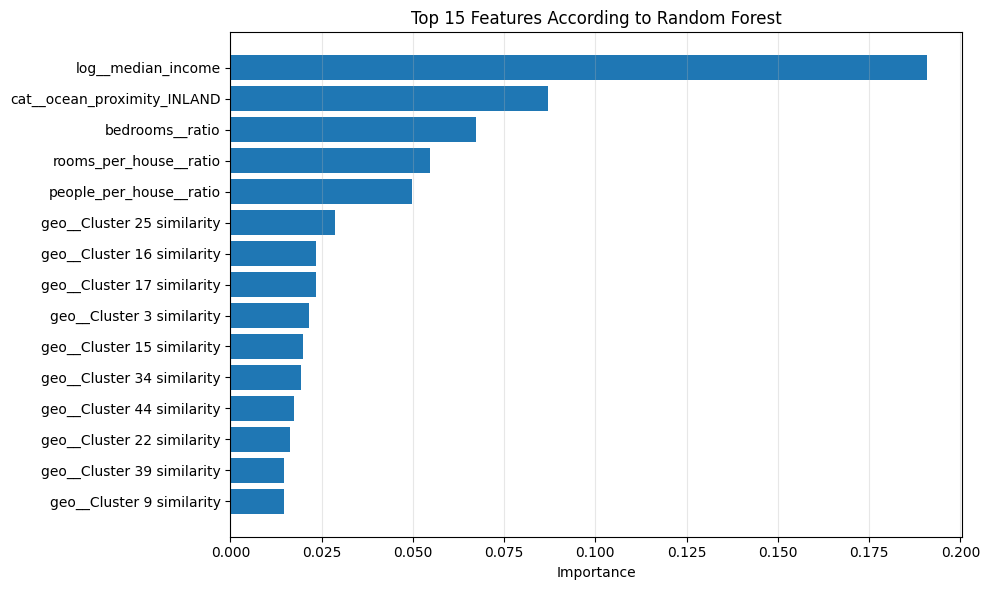

In [134]:
# Visualization: which features actually contribute
import matplotlib.pyplot as plt

top_n = 15
top_feats = importances_df.head(top_n).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_feats['feature'], top_feats['importance'])
ax.set_xlabel('Importance')
ax.set_title(f'Top {top_n} Features According to Random Forest')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Typical observations in this dataset:**

- `log__median_income` usually leads by a wide margin (income is **the strongest predictor** of housing prices.)
- The **ratios** we manually built (`bedrooms__ratio`, `rooms_per_house__ratio`, `people_per_house__ratio`) are usually in the top, which validates the feature engineering done in section 6.
- Some categories of `ocean_proximity` contribute a lot (typically `INLAND`) and others almost nothing (`ISLAND`, `NEAR BAY`).
- Geographic clusters (`geo__Cluster X similarity`) vary greatly from one another: only a few are actually useful.

### 12.2 Least Useful Features: Can They Be Removed?

Features with very low importance (close to zero) are candidates for removal. This can:
- Reduce training time.
- Make the model more interpretable.
- Sometimes even **improve generalization** (less noise).

In [135]:
# How many features have "negligible" importance
umbral = 0.005  # less than 0.5% importance

low_util = importances_df[importances_df['importance'] < umbral]
print(f"Features with importance < {umbral}: {len(low_util)} out of {len(importances_df)}")
print()
print('=== Least Useful Features ===')
print(low_util.to_string(index=False, float_format='{:.4f}'.format))

Features with importance < 0.005: 9 out of 59

=== Least Useful Features ===
                        feature  importance
     geo__Cluster 29 similarity      0.0045
     geo__Cluster 10 similarity      0.0041
      geo__Cluster 5 similarity      0.0037
     geo__Cluster 18 similarity      0.0027
cat__ocean_proximity_NEAR OCEAN      0.0021
 cat__ocean_proximity_<1H OCEAN      0.0018
     geo__Cluster 13 similarity      0.0015
  cat__ocean_proximity_NEAR BAY      0.0004
    cat__ocean_proximity_ISLAND      0.0000


### 12.3 Automatic Selection with `SelectFromModel`

Sklearn offers `SelectFromModel`, a transformer that automates this process: it trains a model (typically a Random Forest), looks at its `feature_importances_`, and discards the least useful ones based on a threshold. The beauty of it is that it integrates right into the pipeline.

In [136]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# Pipeline with automatic feature selection
# 1) preprocessing (same as always)
# 2) SelectFromModel: trains an auxiliary RF and keeps only the important features
# 3) final RandomForest, trained only on the selected features
pipeline_with_selection = Pipeline([
    ("preprocessing", preprocessing),
    ("selector", SelectFromModel(
        RandomForestRegressor(n_estimators=50, random_state=42),
        # keeps features whose importance >= the median
        threshold="median",   
    )),
    ("random_forest", RandomForestRegressor(random_state=42,)),
])

optimal_params = {
    'preprocessing__geo__n_clusters': rnd_search.best_params_['preprocessing__geo__n_clusters'],
    'random_forest__max_features':    rnd_search.best_params_['random_forest__max_features'],
}
pipeline_with_selection.set_params(**optimal_params)

# We evaluate with cross-validation (3 folds to make it fast)
rmse_seleccion = -cross_val_score(
    pipeline_with_selection,
    X_train_f, y_train_f,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
).mean()

print(f'RMSE with automatic feature selection: {rmse_seleccion:,.0f}')
print(f'RMSE of the best model (rnd_search):        {-rnd_search.best_score_:,.0f}')
print()
print('If the values are similar, we can stick with the simpler model,')
print('which trains faster and uses less memory in production.')

RMSE with automatic feature selection: 43,787
RMSE of the best model (rnd_search):        42,166

If the values are similar, we can stick with the simpler model,
which trains faster and uses less memory in production.


---

## 13. Final Evaluation on the Test Set

Up to this point, we did everything on `X_train_f` / `y_train_f`. **It is time to touch the test set for the first time** and get an honest estimate of the generalization error.

> **Golden rule**: once you look at the test set, **you can no longer** tune hyperparameters based on its result. If you do, you contaminate the estimate and no longer have a reliable measure of real-world behavior.

In [137]:
# We retrieve the already separated test set (we did this in the StratifiedShuffleSplit section)
# X_test_f, y_test_f are already defined

# Final predictions (the pipeline applies all the preprocessing for us)
final_predictions = final_model.predict(X_test_f)

# RMSE on test
final_rmse = root_mean_squared_error(y_test_f, final_predictions)
print(f'RMSE on TEST SET:                  {final_rmse:>10,.0f}')
print(f'RMSE on CV (train validation):     {-rnd_search.best_score_:>10,.0f}')
print()

RMSE on TEST SET:                      41,371
RMSE on CV (train validation):         42,166



### 13.1 Confidence Interval with `bootstrap`

A single number (RMSE = X) **does not tell us how precise that estimate is**. Perhaps with another test sample we would get a very different RMSE. To quantify this uncertainty we use **bootstrap**: we resample the errors with replacement thousands of times and look at how the RMSE is distributed.

`scipy.stats.bootstrap` automates this and returns a confidence interval.

In [138]:
from scipy import stats

def rmse_of_squared_errors(errors_square):
    """Statistical function for bootstrap: given an array of squared errors,
    returns the RMSE."""
    return np.sqrt(np.mean(errors_square))

trust = 0.95
quadratic_errors = (final_predictions - y_test_f) ** 2

result_boot = stats.bootstrap(
    [quadratic_errors],
    rmse_of_squared_errors,
    confidence_level=trust,
    n_resamples=10_000,
    random_state=42,
)

rmse_lower, rmse_upper = result_boot.confidence_interval

print(f'=== {trust*100:.0f}% Confidence Interval for the RMSE ===')
print(f'  Lower bound: {rmse_lower:>10,.0f}')
print(f'  Estimate:    {final_rmse:>10,.0f}')
print(f'  Upper bound: {rmse_upper:>10,.0f}')
print()
print(f'That is, with {trust*100:.0f}% confidence, the true generalization RMSE')
print(f'is between {rmse_lower:,.0f} and {rmse_upper:,.0f}.')

=== 95% Confidence Interval for the RMSE ===
  Lower bound:     39,457
  Estimate:        41,371
  Upper bound:     43,607

That is, with 95% confidence, the true generalization RMSE
is between 39,457 and 43,607.


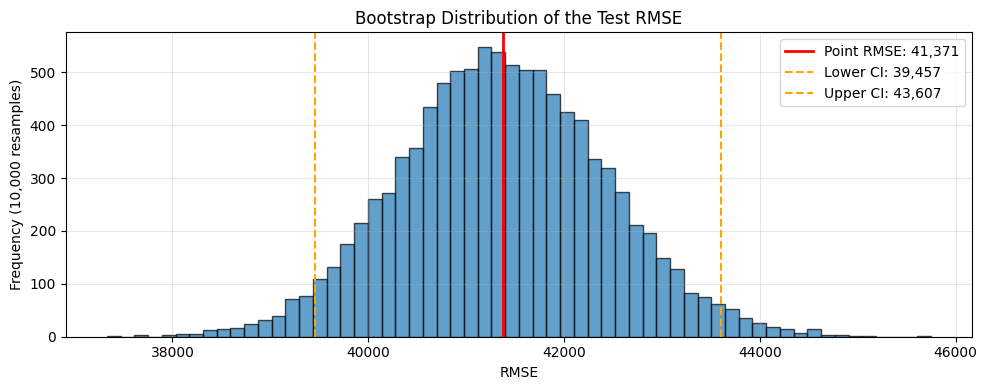

In [139]:
# We visualize the bootstrap distribution
plt.figure(figsize=(10, 4))
plt.hist(result_boot.bootstrap_distribution, bins=60, edgecolor='black', alpha=0.7)
plt.axvline(final_rmse, color='red', linewidth=2, label=f'Point RMSE: {final_rmse:,.0f}')
plt.axvline(rmse_lower, color='orange', linestyle='--', label=f'Lower CI: {rmse_lower:,.0f}')
plt.axvline(rmse_upper, color='orange', linestyle='--', label=f'Upper CI: {rmse_upper:,.0f}')
plt.xlabel('RMSE')
plt.ylabel('Frequency (10,000 resamples)')
plt.title('Bootstrap Distribution of the Test RMSE')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Why does the confidence interval matter?**

Imagine that the production model has a known RMSE of **42,000** and your new model gives **41,800** on test. It looks better… but if the confidence interval is **[39,500, 44,200]**, that 41,800 could perfectly be compatible with a real RMSE of 43,000 (worse than the current one). The interval tells us **how much evidence** there is to replace the system.

---

## 15. Saving and Loading the Model with `cloudpickle`

We already have a trained and validated model. To take it to production, we need to **persist it**: save the full pipeline (preprocessing + model) into a file, transfer it to the production server, and load it from there.

Although `joblib` is the standard option for sklearn, in this case we combine it with `cloudpickle` because our pipeline contains a `lambda` (in the `FunctionTransformer` of `ratio_pipeline`) that standard `pickle` cannot handle.

In [140]:
import cloudpickle
from pathlib import Path
from datetime import datetime
import json

# Folder to save model artifacts
models_dir = Path('models')
models_dir.mkdir(exist_ok=True)

# We version by date to avoid overwriting previous versions
version = datetime.now().strftime('%Y%m%d_%H%M')
model_route = models_dir / f'california_housing_v{version}.pkl'
latest_route = models_dir / 'california_housing_latest.pkl'

# We save the COMPLETE pipeline (preprocessing + RandomForest)
# We use cloudpickle instead of joblib.dump because the pipeline contains a lambda
# (in ratio_pipeline -> FunctionTransformer(feature_names_out=lambda...)).
# Standard pickle cannot serialize lambdas, but cloudpickle can.
with open(model_route, 'wb') as f:
    cloudpickle.dump(final_model, f)

# We also save a 'latest' alias so that production always loads the latest one
with open(latest_route, 'wb') as f:
    cloudpickle.dump(final_model, f)

# And we save a metadata file with the training details
metadata = {
    'version': version,
    'training_date': datetime.now().isoformat(),
    'rmse_cv': float(-rnd_search.best_score_),
    'rmse_test': float(final_rmse),
    'rmse_test_ci_95': [float(rmse_lower), float(rmse_upper)],
    'best_hyperparameters': {k: int(v) for k, v in rnd_search.best_params_.items()},
    'n_features': int(len(feature_names)),
    'n_train_samples': int(len(X_train_f)),
    # important to know what to load with
    'serializer': 'cloudpickle',  
}

with open(models_dir / f'metadata_v{version}.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'Model saved to: {model_route}')
print(f'File size: {model_route.stat().st_size / 1024 / 1024:.1f} MB')
print()
print('Metadata:')
print(json.dumps(metadata, indent=2))

Model saved to: models\california_housing_v20260531_2335.pkl
File size: 138.2 MB

Metadata:
{
  "version": "20260531_2335",
  "training_date": "2026-05-31T23:35:43.160558",
  "rmse_cv": 42166.363844742744,
  "rmse_test": 41371.21740583231,
  "rmse_test_ci_95": [
    39456.77336794742,
    43607.18551495643
  ],
  "best_hyperparameters": {
    "preprocessing__geo__n_clusters": 45,
    "random_forest__max_features": 9
  },
  "n_features": 59,
  "n_train_samples": 16512,
  "serializer": "cloudpickle"
}


### 15.1 Loading the Model and Making Predictions

This is how the model would be used in production. Since we saved with `cloudpickle`, **we must also load with `cloudpickle`** (not with `joblib.load`).

Important: before loading, we must have imported the custom classes (`ClusterSimilarity`, `column_ratio`, `ratio_pipeline`), because cloudpickle saves references to the module's classes, not their full definition when they are in `__main__`.

In [141]:
# We simulate a production scenario: loading the model and predicting on new data
# (In real life, this would happen in another process/server)
import cloudpickle

with open(models_dir / 'california_housing_latest.pkl', 'rb') as f:
    model_loaded = cloudpickle.load(f)

# We take 5 districts from the test set as if they were "new data"
new_districts = X_test_f.head(5).copy()
print('=== Input Data (5 districts) ===')
print(new_districts[['median_income', 'total_rooms', 'population', 'ocean_proximity']])
print()

# Prediction: the loaded pipeline applies ALL the preprocessing automatically
new_predictions = model_loaded.predict(new_districts)
real_values = y_test_f.head(5).values

resultado = pd.DataFrame({
    'real_price':      real_values,
    'predicted_price': new_predictions,
    'error':           new_predictions - real_values,
    'error_pct':       (new_predictions - real_values) / real_values * 100,
})
print('=== Predictions ===')
print(resultado.to_string(float_format='{:,.0f}'.format))

=== Input Data (5 districts) ===
       median_income  total_rooms  population ocean_proximity
3905          7.7360       2387.0       913.0       <1H OCEAN
16821         4.6354       1589.0       804.0       <1H OCEAN
2900          4.0968       5915.0      2136.0      NEAR OCEAN
7193          4.1310       2166.0      1072.0      NEAR OCEAN
13928         3.6037       1405.0       725.0        NEAR BAY

=== Predictions ===
   real_price  predicted_price  error  error_pct
0     397,700          419,460 21,760          5
1     202,900          213,512 10,612          5
2     310,000          349,927 39,927         13
3     314,300          330,213 15,913          5
4     187,500          270,458 82,958         44


### 15.2 Notes for Real Production

In a serious deployment, in addition to the `.pkl`, we should version/package:

- **The code** of the custom classes (`ClusterSimilarity`, transformers, etc.) — ideally in an installable package.
- **`requirements.txt`** with the exact versions of `scikit-learn`, `numpy`, `scipy`, `pandas`,  cloudpickle`. A different version of sklearn may prevent loading the pickle.
- **The input schema** (what columns it expects, what types) — useful for validating requests before calling `predict()`.
- **Training metrics** (like our `metadata.json`) for auditing.

**About cloudpickle vs more robust alternatives:**
- `cloudpickle` solves the lambdas problem but still has the limitations of pickle: dependent on Python/sklearn versions, insecure if coming from untrusted sources.
- Alternatives for serious production: **ONNX** (open standard format, no code execution), **Skops** (secure alternative for sklearn), **MLflow Models** (complete packaging with dependencies).